# PTB Diagnostic Database Analysis

## Setup

### Packages

Upgrading some packages requires restarting the Colab runtime.
Check that they are installed and up to date to avoid having to restart later.

In [1]:
#!pip install --upgrade ydata_profiling matplotlib tensorflow_addons "lightgbm<4.0.0"

### Data

In [1]:
PATH = "ptb-diagnostic-ecg-database-1.0.0"
ZIP = f"{PATH}.zip"
URL = f"https://www.physionet.org/static/published-projects/ptbdb/{ZIP}"

In [2]:
import os
# try:
#     from google.colab import drive
#     mount_point = os.path.join(os.path.sep, "content", "drive")
#     drive.mount(mount_point)
#     PATH = os.path.join(mount_point, "My Drive", PATH)
# except ImportError:
#     pass
# SHELL_PATH = "\"" + PATH + "\""

In [3]:
#![ ! -d {SHELL_PATH} ] && wget -N -c {URL} && unzip -qq {ZIP}

## Exploration

### Content

List the contents of the main directory:

In [5]:
sorted(os.listdir(PATH))

['CONTROLS',
 'README',
 'RECORDS',
 'SHA256SUMS.txt',
 'patient001',
 'patient002',
 'patient003',
 'patient004',
 'patient005',
 'patient006',
 'patient007',
 'patient008',
 'patient009',
 'patient010',
 'patient011',
 'patient012',
 'patient013',
 'patient014',
 'patient015',
 'patient016',
 'patient017',
 'patient018',
 'patient019',
 'patient020',
 'patient021',
 'patient022',
 'patient023',
 'patient024',
 'patient025',
 'patient026',
 'patient027',
 'patient028',
 'patient029',
 'patient030',
 'patient031',
 'patient032',
 'patient033',
 'patient034',
 'patient035',
 'patient036',
 'patient037',
 'patient038',
 'patient039',
 'patient040',
 'patient041',
 'patient042',
 'patient043',
 'patient044',
 'patient045',
 'patient046',
 'patient047',
 'patient048',
 'patient049',
 'patient050',
 'patient051',
 'patient052',
 'patient053',
 'patient054',
 'patient055',
 'patient056',
 'patient057',
 'patient058',
 'patient059',
 'patient060',
 'patient061',
 'patient062',
 'patient063',


There are some general information and subfolders organised by patient.

List a subdirectory, e.g. `patient001`:

In [6]:
import datetime
import humanize
import pandas as pd

patient_path = os.path.join(PATH, "patient001")
patient_file_info = [
    [
        file.name,
        humanize.naturalsize(file.stat().st_size),
        str(datetime.datetime.fromtimestamp(file.stat().st_mtime))
    ]
    for file in os.scandir(patient_path)
]
patient_file_info = sorted(patient_file_info)
patient_file_df = pd.DataFrame(
    patient_file_info,
    columns=["file", "size", "timestamp"]
)
patient_file_df

,file,size,timestamp
0,s0010_re.dat,921.6 kB,2004-08-03 18:00:00
1,s0010_re.hea,2.7 kB,2016-03-22 15:12:04
2,s0010_re.xyz,230.4 kB,2004-08-03 18:00:00
3,s0014lre.dat,2.8 MB,2004-08-03 18:00:00
4,s0014lre.hea,2.7 kB,2016-03-22 15:12:04
5,s0014lre.xyz,691.2 kB,2004-08-03 18:00:00
6,s0016lre.dat,2.8 MB,2004-08-03 18:00:00
7,s0016lre.hea,2.7 kB,2016-03-22 15:12:06
8,s0016lre.xyz,691.2 kB,2004-08-03 18:00:00


Files appear in groups of three, a `.dat`, a `.hea`, and a `.xyz`.
Looking at sizes:

- `.hea` are small around a few kB,
- `.xyz` are medium at few hundred kB,
- `.dat` are large around a few MB.

Note that **numberings are not consecutive** (0010, 0014, 0016) and there are **two endings** (`_re` and `lre`).

Try to read the `.hea`:

In [7]:
hea_path = os.path.join(patient_path, "s0010_re.hea")
with open(hea_path) as hea_file:
    print(hea_file.read())

s0010_re 15 1000 38400
s0010_re.dat 16 2000 16 0 -489 -8337 0 i
s0010_re.dat 16 2000 16 0 -458 -16369 0 ii
s0010_re.dat 16 2000 16 0 31 6829 0 iii
s0010_re.dat 16 2000 16 0 474 4582 0 avr
s0010_re.dat 16 2000 16 0 -260 11687 0 avl
s0010_re.dat 16 2000 16 0 -214 -16657 0 avf
s0010_re.dat 16 2000 16 0 -88 -12469 0 v1
s0010_re.dat 16 2000 16 0 -241 5636 0 v2
s0010_re.dat 16 2000 16 0 -112 -14299 0 v3
s0010_re.dat 16 2000 16 0 212 -17916 0 v4
s0010_re.dat 16 2000 16 0 393 -6668 0 v5
s0010_re.dat 16 2000 16 0 390 -17545 0 v6
s0010_re.xyz 16 2000 16 0 -3 -13009 0 vx
s0010_re.xyz 16 2000 16 0 120 7109 0 vy
s0010_re.xyz 16 2000 16 0 -18 -1992 0 vz

# age: 81
# sex: female
# ECG date: 01/10/1990

# Diagnose:
# Reason for admission: Myocardial infarction
# Acute infarction (localization): infero-latera
# Former infarction (localization): no
# Additional diagnoses: Diabetes mellitus
# Smoker: no
# Number of coronary vessels involved: 1
# Infarction date (acute): 29-Sep-90
# Previous infarction (1

Luckily this is human-readable.

- The first part gives some technical data - note the lead identifiers and which file they are contained in.
- The second part gives clinial metadata!

There is also a "global" `RECORDS` file, let's read it.

In [8]:
records_path = os.path.join(PATH, "RECORDS")
with open(records_path) as records_file:
    print(records_file.read())

patient001/s0010_re
patient001/s0014lre
patient001/s0016lre
patient002/s0015lre
patient003/s0017lre
patient004/s0020are
patient004/s0020bre
patient005/s0021are
patient005/s0021bre
patient005/s0025lre
patient005/s0031lre
patient005/s0101lre
patient006/s0022lre
patient006/s0027lre
patient006/s0064lre
patient007/s0026lre
patient007/s0029lre
patient007/s0038lre
patient007/s0078lre
patient008/s0028lre
patient008/s0037lre
patient008/s0068lre
patient009/s0035_re
patient010/s0036lre
patient010/s0042lre
patient010/s0061lre
patient011/s0039lre
patient011/s0044lre
patient011/s0049lre
patient011/s0067lre
patient012/s0043lre
patient012/s0050lre
patient013/s0045lre
patient013/s0051lre
patient013/s0072lre
patient014/s0046lre
patient014/s0056lre
patient014/s0071lre
patient015/s0047lre
patient015/s0057lre
patient015/s0152lre
patient016/s0052lre
patient016/s0060lre
patient016/s0076lre
patient017/s0053lre
patient017/s0055lre
patient017/s0063lre
patient017/s0075lre
patient018/s0054lre
patient018/s0059lre


Looks like a list of every ECG in the dataset, let's read it in a dataframe.

In [9]:
records_df = pd.read_csv(records_path, header=None, names=["name"])
records_df["patient"] = records_df["name"].apply(lambda x: x.split("/")[0])
records_df["id"] = records_df["name"].apply(lambda x: x.split("/")[-1])
records_df["ending"] = records_df["id"].apply(lambda x: x[-3:])
records_df["id"] = records_df["id"].apply(lambda x: x[:-3])
records_df

,name,patient,id,ending
0,patient001/s0010_re,patient001,s0010,_re
1,patient001/s0014lre,patient001,s0014,lre
2,patient001/s0016lre,patient001,s0016,lre
3,patient002/s0015lre,patient002,s0015,lre
4,patient003/s0017lre,patient003,s0017,lre
...,...,...,...,...
544,patient292/s0555_re,patient292,s0555,_re
545,patient292/s0556_re,patient292,s0556,_re
546,patient293/s0557_re,patient293,s0557,_re
547,patient293/s0558_re,patient293,s0558,_re


The 3-character codes at the end of the naming scheme are not self-explanatory.

Maybe some statistics can help to understand them?

In [10]:
records_df["ending"].value_counts().sort_index()

ending
_re    170
are      5
bre      5
cre      1
lre    368
Name: count, dtype: int64

This is a good question for the customer, or ideally the person who collected the data.

**Learnings**

- Getting an elementary background in the topic pays off:
even ECG lead acronyms would have been difficult to interpret otherwise.
- Some dataset features may be obscure even to the best data scientist,
it usually is a good idea to ask the data provider for clarifications.

**Task 2.1**

What aspects of the dataset should be investigated?
Which statistics and plots would be interesting to understand it?

*Answer*: demographics, outliers, how many ECG's per patient, correlation...
- mapping of synonyms (make a hirearchy in level of detail/class)
- typos, capitalization, misspelling

### Basic stats

Start with counting the number of patients in the dataset,
and how many files per patient are available.

In [11]:
patient_dirs = sorted(x for x in os.listdir(PATH) if x.startswith("patient"))
len(patient_dirs)

290

The patients with the lowest and highest number are

In [12]:
first_patient_string = patient_dirs[0]
last_patient_string = patient_dirs[-1]
print(first_patient_string, last_patient_string)

patient001 patient294


There are clearly some patients whose records are missing.
Their numbers are

In [13]:
first_patient_number = int(first_patient_string[-3:])
last_patient_number = int(last_patient_string[-3:])
missing_patient_numbers = [
    n for n in range(first_patient_number, last_patient_number + 1)
    if f"patient{n:03}" not in patient_dirs
]
missing_patient_numbers

[124, 132, 134, 161]

They do not really reveal a pattern,
it is reasonable to assume that they were discarded from the study for some reason
(e.g. corrupted data).

Next, it should be checked how many ECG recordings per patient are available.

In [14]:
ecgs_per_patient = {}
for patient_dir in patient_dirs:
    patient_path_ = os.path.join(PATH, patient_dir)
    header_filenames = [filename for filename in os.listdir(patient_path_) if filename.endswith(".hea")]
    ecgs_per_patient[patient_dir] = len(header_filenames)

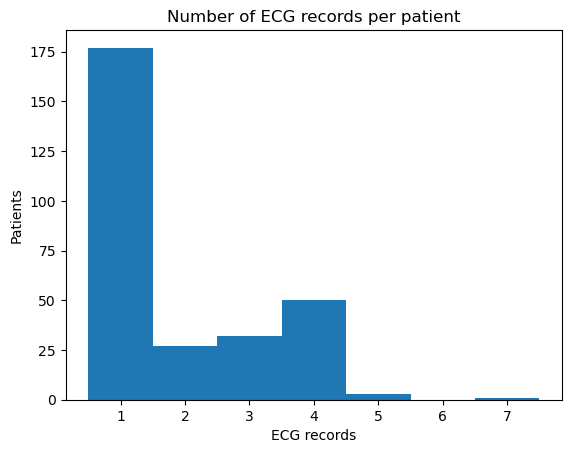

In [15]:
import matplotlib.pyplot as plt
xs = ecgs_per_patient.values()
bins = max(xs) - min(xs) + 1
range_ = (min(xs) - 0.5, max(xs) + 0.5)
plt.hist(xs, range=range_, bins=bins)
plt.title("Number of ECG records per patient")
plt.xlabel("ECG records")
plt.ylabel("Patients")
plt.show()

The dataset description states that there are up to 5 recordings per patient.
The data seems to disagree.
A good check is to find out which data are responsible,
in this case the patients with 7 ECG recordings.

In [16]:
patients_7 = [patient for patient in patient_dirs if ecgs_per_patient[patient] == 7]
patients_7

['patient180']

Now check the available header files.

In [17]:
patient_7_path = os.path.join(PATH, patients_7[0])
sorted(filename for filename in os.listdir(patient_7_path) if filename.endswith(".hea"))

['s0374lre.hea',
 's0475_re.hea',
 's0476_re.hea',
 's0477_re.hea',
 's0490_re.hea',
 's0545_re.hea',
 's0561_re.hea']

It is easy to check that this is a healthy control patient with ECGs from 1992 to 1997,
including one with unregistered date.
(What a dedication!)

Also note that the age is always registered to be the same...


**Learnings**

- Look for patterns in data organisation: it usually pays off.
- In case of inconsistencies, it is a good idea to explore in detail
and discuss them with data providers.

### Reading records

Browsing the web,
it is easy to discover that the dataset has a relatively standard format
and there is a `python` library to read/write files.
It is called [`wfdb`](https://github.com/MIT-LCP/wfdb-python),
it has a documented [API](https://wfdb.readthedocs.io),
and indications on how to properly [cite the work](https://physionet.org/content/wfdb-python/4.0.0/).

Take the first record of the first patient and have a look.

In [18]:
#!pip install wfdb

In [19]:
import wfdb
record_name = os.path.join(patient_path, "s0010_re")
signals, fields = wfdb.rdsamp(record_name)
print(signals) # matrix of float values for each of the 15 leads
print(fields) # dictionary of metadata including clinical information

[[-0.2445 -0.229   0.0155 ... -0.0015  0.06   -0.009 ]
 [-0.2425 -0.2335  0.009  ... -0.0015  0.061  -0.01  ]
 [-0.2415 -0.2345  0.007  ... -0.0035  0.0555 -0.0085]
 ...
 [ 0.152   0.2695  0.118  ...  0.079   0.036   0.031 ]
 [ 0.136   0.256   0.1205 ...  0.081   0.042   0.03  ]
 [ 0.135   0.2585  0.1245 ...  0.081   0.049   0.029 ]]
{'fs': 1000, 'sig_len': 38400, 'n_sig': 15, 'base_date': None, 'base_time': None, 'units': ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], 'sig_name': ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'vx', 'vy', 'vz'], 'comments': ['age: 81', 'sex: female', 'ECG date: 01/10/1990', 'Diagnose:', 'Reason for admission: Myocardial infarction', 'Acute infarction (localization): infero-latera', 'Former infarction (localization): no', 'Additional diagnoses: Diabetes mellitus', 'Smoker: no', 'Number of coronary vessels involved: 1', 'Infarction date (acute): 29-Sep-90', 'Previous infarction (1)

`signals` is a matrix of floating-point numbers,
`fields` is a dictionary with metadata including clinical information.

The shape of `signals` is also interesting to look at:

In [20]:
signals.shape

(38400, 15)

There are 38400 values for each of the 15 leads.

Now it makes sense to read the whole data
(and also to have a progress bar).

In [21]:
from tqdm.auto import tqdm
all_signals = []
all_fields = []
for record_name_ in tqdm(records_df["name"]):
    record_path = os.path.join(PATH, record_name_)
    signals, fields = wfdb.rdsamp(record_path)
    all_signals.append(signals)
    all_fields.append(fields)
records_df["signals"] = all_signals
records_df["fields"] = all_fields
records_df

  0%|          | 0/549 [00:00<?, ?it/s]

,name,patient,id,ending,signals,fields
0,patient001/s0010_re,patient001,s0010,_re,"[[-0.2445, -0.229, 0.0155, 0.237, -0.13, -0.10...","{'fs': 1000, 'sig_len': 38400, 'n_sig': 15, 'b..."
1,patient001/s0014lre,patient001,s0014,lre,"[[-0.474, -0.0595, 0.415, 0.267, -0.445, 0.178...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
2,patient001/s0016lre,patient001,s0016,lre,"[[0.254, 0.7535, 0.499, -0.5035, -0.1225, 0.62...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
3,patient002/s0015lre,patient002,s0015,lre,"[[0.2735, -0.035, -0.308, -0.119, 0.291, -0.17...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
4,patient003/s0017lre,patient003,s0017,lre,"[[-0.6195, -0.9435, -0.3235, 0.782, -0.1475, -...","{'fs': 1000, 'sig_len': 115200, 'n_sig': 15, '..."
...,...,...,...,...,...,...
544,patient292/s0555_re,patient292,s0555,_re,"[[-0.5035, 1.6195, 2.124, -0.558, -1.314, 1.87...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."
545,patient292/s0556_re,patient292,s0556,_re,"[[0.8055, -0.2945, -1.1, -0.2555, 0.9535, -0.6...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."
546,patient293/s0557_re,patient293,s0557,_re,"[[-1.1685, -1.672, -0.5035, 1.42, -0.333, -1.0...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."
547,patient293/s0558_re,patient293,s0558,_re,"[[0.6085, 0.134, -0.4735, -0.371, 0.541, -0.16...","{'fs': 1000, 'sig_len': 120012, 'n_sig': 15, '..."


At this stage, the column `"fields"` contains a lot of semi-organised information;
it can be unpacked in further dataframe columns.

In [22]:
fields = records_df["fields"][0].keys()
for field in fields:
    records_df[field] = records_df["fields"].apply(lambda x: x[field])
records_df.drop(columns=["fields"], inplace=True)
records_df

,name,patient,id,ending,signals,fs,sig_len,n_sig,base_date,base_time,units,sig_name,comments
0,patient001/s0010_re,patient001,s0010,_re,"[[-0.2445, -0.229, 0.0155, 0.237, -0.13, -0.10...",1000,38400,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 81, sex: female, ECG date: 01/10/1990, D..."
1,patient001/s0014lre,patient001,s0014,lre,"[[-0.474, -0.0595, 0.415, 0.267, -0.445, 0.178...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 81, sex: female, ECG date: 17/10/1990, D..."
2,patient001/s0016lre,patient001,s0016,lre,"[[0.254, 0.7535, 0.499, -0.5035, -0.1225, 0.62...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 81, sex: female, ECG date: 18/10/1990, D..."
3,patient002/s0015lre,patient002,s0015,lre,"[[0.2735, -0.035, -0.308, -0.119, 0.291, -0.17...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 58, sex: female, ECG date: 17/10/1990, D..."
4,patient003/s0017lre,patient003,s0017,lre,"[[-0.6195, -0.9435, -0.3235, 0.782, -0.1475, -...",1000,115200,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 63, sex: male, ECG date: 18/10/1990, Dia..."
...,...,...,...,...,...,...,...,...,...,...,...,...,...
544,patient292/s0555_re,patient292,s0555,_re,"[[-0.5035, 1.6195, 2.124, -0.558, -1.314, 1.87...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 66, sex: male, ECG date: 03/06/1997, Dia..."
545,patient292/s0556_re,patient292,s0556,_re,"[[0.8055, -0.2945, -1.1, -0.2555, 0.9535, -0.6...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 66, sex: male, ECG date: 03/06/1997, Dia..."
546,patient293/s0557_re,patient293,s0557,_re,"[[-1.1685, -1.672, -0.5035, 1.42, -0.333, -1.0...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 75, sex: male, ECG date: 03/06/1997, Dia..."
547,patient293/s0558_re,patient293,s0558,_re,"[[0.6085, 0.134, -0.4735, -0.371, 0.541, -0.16...",1000,120012,15,None,None,"[mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, mV, m...","[i, ii, iii, avr, avl, avf, v1, v2, v3, v4, v5...","[age: 75, sex: male, ECG date: 03/06/1997, Dia..."


Much of the information is still packed in the `"comments"` column,
here is the example from the first record:

In [23]:
records_df["comments"][0]

['age: 81',
 'sex: female',
 'ECG date: 01/10/1990',
 'Diagnose:',
 'Reason for admission: Myocardial infarction',
 'Acute infarction (localization): infero-latera',
 'Former infarction (localization): no',
 'Additional diagnoses: Diabetes mellitus',
 'Smoker: no',
 'Number of coronary vessels involved: 1',
 'Infarction date (acute): 29-Sep-90',
 'Previous infarction (1) date: n/a',
 'Previous infarction (2) date: n/a',
 'Hemodynamics:',
 'Catheterization date: 16-Oct-90',
 'Ventriculography: Akinesia inferior wall',
 'Chest X-ray: Heart size upper limit of norm',
 'Peripheral blood Pressure (syst/diast):  140/80 mmHg',
 'Pulmonary artery pressure (at rest) (syst/diast): n/a',
 'Pulmonary artery pressure (at rest) (mean): n/a',
 'Pulmonary capillary wedge pressure (at rest): n/a',
 'Cardiac output (at rest): n/a',
 'Cardiac index (at rest): n/a',
 'Stroke volume index (at rest): n/a',
 'Pulmonary artery pressure (laod) (syst/diast): n/a',
 'Pulmonary artery pressure (laod) (mean): n/a'

These are strings in the format `"key: values"`,
first find all possible keys.

In [24]:
import itertools
all_comments = itertools.chain(*records_df["comments"])
all_comment_keys = sorted(set(x.split(":")[0] for x in all_comments))
all_comment_keys

['Acute infarction (localization)',
 'Additional diagnoses',
 'Additional medication',
 'Admission date',
 'Aorta (at rest) (syst/diast)',
 'Aorta (at rest) mean',
 'Cardiac index (at rest)',
 'Cardiac index (load)',
 'Cardiac output (at rest)',
 'Cardiac output (load)',
 'Catheterization date',
 'Chest X-ray',
 'Diagnose',
 'Dosage (lytic agent)',
 'ECG date',
 'Echocardiography',
 'Former infarction (localization)',
 'Hemodynamics',
 'In hospital medication',
 'Infarction date',
 'Infarction date (acute)',
 'Left coronary artery stenoses (RCX)',
 'Left coronary artery stenoses (RIVA)',
 'Left ventricular enddiastolic pressure',
 'Lytic agent',
 'Medication after discharge',
 'Medication pre admission',
 'Number of coronary vessels involved',
 'Peripheral blood Pressure (syst/diast)',
 'Previous infarction (1) date',
 'Previous infarction (2) date',
 'Pulmonary artery pressure (at rest) (mean)',
 'Pulmonary artery pressure (at rest) (syst/diast)',
 'Pulmonary artery pressure (laod) (m

Now unroll all information in columns of `records_df`,
and eliminate whitespaces at the head of the values string.

In [25]:
def no_start_whitespace(x: str) -> str:
    return x[1:] if x.startswith(" ") else x
comment_dicts = [
    {comment.split(":")[0]: no_start_whitespace(comment.split(":")[1]) for comment in comments}
    for comments in records_df["comments"]
]
for comment_key in all_comment_keys:
    records_df[comment_key] = [
        comment_dict.get(comment_key, None)
        for comment_dict in comment_dicts
    ]
records_df.drop(columns=["comments"], inplace=True)
records_df.columns

Index(['name', 'patient', 'id', 'ending', 'signals', 'fs', 'sig_len', 'n_sig',
       'base_date', 'base_time', 'units', 'sig_name',
       'Acute infarction (localization)', 'Additional diagnoses',
       'Additional medication', 'Admission date',
       'Aorta (at rest) (syst/diast)', 'Aorta (at rest) mean',
       'Cardiac index (at rest)', 'Cardiac index (load)',
       'Cardiac output (at rest)', 'Cardiac output (load)',
       'Catheterization date', 'Chest X-ray', 'Diagnose',
       'Dosage (lytic agent)', 'ECG date', 'Echocardiography',
       'Former infarction (localization)', 'Hemodynamics',
       'In hospital medication', 'Infarction date', 'Infarction date (acute)',
       'Left coronary artery stenoses (RCX)',
       'Left coronary artery stenoses (RIVA)',
       'Left ventricular enddiastolic pressure', 'Lytic agent',
       'Medication after discharge', 'Medication pre admission',
       'Number of coronary vessels involved',
       'Peripheral blood Pressure (syst/dia

### Features

**Task 2.2** What should we look at in this dataset?

There are tools to get automated reports.
Try to use `ydata_profiling` out of the box with data in the current format.

In [26]:
from ydata_profiling import ProfileReport
no_signals_df = records_df.drop(columns=["signals"])
profile = ProfileReport(no_signals_df, title="ECG dataset report draft")
profile.to_file("ecg_report_draft.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Observations:

- Some features are trivial, i.e. constant across the whole dataset.
- `ydata_profiling` reports missing values, but is not smart enough to understand that the string "n/a" means missing.
- Likewise, many features are strings which include units, and should be converted to floating point numbers.
- Dates have different formats and should be converted to machine-understandable formats.
- Some variables are actually lists of medical observations, and should be encoded differently.
- Variables that are largely missing are probably not very useful for machine learning (will inevitably lead to overfitting).

Some data wrangling is in order.
Start by eliminating trivial features.

In [27]:
for column in records_df.columns:
    if column == "signals":
        continue
    try:
        column_uniques = records_df[column].unique()
    except TypeError:
        column_uniques = records_df[column].drop_duplicates()
    if len(column_uniques) == 1:
        print(f"{column} is always {column_uniques[0]}, deleting")
        records_df.drop(columns=[column], inplace=True)

fs is always 1000, deleting
n_sig is always 15, deleting
base_date is always None, deleting
base_time is always None, deleting
units is always ['mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV', 'mV'], deleting
sig_name is always ['i', 'ii', 'iii', 'avr', 'avl', 'avf', 'v1', 'v2', 'v3', 'v4', 'v5', 'v6', 'vx', 'vy', 'vz'], deleting
Diagnose is always , deleting
Hemodynamics is always , deleting
Therapy is always , deleting


Look at the value distribution for some features
to get more of a feeling for data quality.

First consider signal length as an indication of how uniform data collection was.

In [28]:
records_df["sig_len"].value_counts().sort_index()

sig_len
32000       3
38400      50
76800       1
87910       1
91987       1
96588       1
97000       1
115174      3
115200    365
118184      1
120012    122
Name: count, dtype: int64

Signal length is mostly standard (38.4s, 115.2s, 120.012s) with a few exceptions.

Now look at a clinical label, in this case choose the localization of acute infarction.

In [29]:
records_df['Acute infarction (localization)'].value_counts().sort_index()

Acute infarction (localization)
anterior                   47
antero-lateral             43
antero-septal              77
antero-septo-lateral        2
inferior                   89
infero-latera               3
infero-lateral             53
infero-poster-lateral       3
infero-posterior            1
infero-postero-lateral     16
lateral                     3
n/a                        27
no                        175
posterior                   4
postero-lateral             5
unknown                     1
Name: count, dtype: int64

Clearly even if the dataset is already very clean,
there are still typos:

- `"infero-latera"` = `"infero-lateral"`
- `"infero-poster-lateral"` = `"infero-postero-lateral"`

Often such basic checks are forgotten,
and a ML model has additional categories which are in reality the same as others.

Some distinctions may be unclear: `"unknown"` vs `"n/a"` vs `"no"`.
A reasonable way to proceed would be to take `"no"` as `"no infarction"`,
and treat `"unknown"` as `"n/a"`,
but it is best to discuss with the data provider!

Another clinical label that could be very interesting are additional diagnoses.

In [30]:
additional_diagnoses = [
    sorted(no_start_whitespace(ad) for ad in ad_str.split(","))
    for ad_str in records_df["Additional diagnoses"]
]
sorted(set(itertools.chain(*additional_diagnoses)))

['ACVB (1x)',
 'ACVB (RIVA)',
 'AV-reentry tachycardia',
 'Adiposis hepatis',
 'Alcohol abuse',
 'Anemia',
 'Aortic regurgitation (grade 2-3)',
 'Aortic stenosis (gradient 90mmHg)',
 'Aortic stenosis (mild)',
 'Aortic stenosis (moderate',
 'Aortic stenosis(gradient 85 mmHg)/regurgitation (grade 1-2)',
 'Aortic valve regurgitation (grade 1)',
 'Aortic valve regurgitation (grade1-2)',
 'Arterial Hypertension',
 'Arterial hypertension',
 'Arteriel hypertension',
 'Asthma bronchiale',
 'Atrial Fibrillation',
 'Atrial fibrillation',
 'Atrial flutter',
 'Basalioma',
 'Bladder cancer',
 'Bundle branch block',
 'COLD',
 'Calcified aortic valve (mild stenosis)',
 'Cardioverter-Defibrillator',
 'Cardioverter-Defibrillator (1993)',
 'Cerebral stroke',
 'Cholesteatoma',
 'Chronic glomerulonephritis',
 'Chronic hepatitis',
 'Chronic lymphatic leucemia',
 'Chronic myocarditis',
 'Colon cancer',
 'Congenital complete AV-block',
 'Coronary artery disease',
 'Coronary artery disease (ACVB 2x)',
 'Coron

Lots of simple but very annoying complications arise:

- capitalisation,
- typos,
- different levels of detail,
- different names for the same conditions.

If these are injected in a ML model without preprocessing,
the model will not know the relationship among terms (e.g. all just "distinct" categories)
and will have a very hard time in figuring them out (large amounts of data needed).

To alleviate this problem,
use **ontologies** such as [ICD](https://icd.who.int/en) (Creative Commons)
or [SNOMED CT](https://www.snomed.org/snomed-ct/five-step-briefing) (commercial).
Note that typos have to be corrected manually if relevant.

### Possible tasks

It is very important to understand the Machine Learning tasks that can be performed with a given dataset,
and if the customer's requests can be satisfied.

**Task 3: what could we do with this dataset?**

Here the focus will be on _classification of ECGs in acute disease classes_,
which are the reason for admission to a hospital.

*Answer*:
- Find patterns in different infarction
- Visualize:
  -dependencies
  - co-morbidities
  - patterns by different classes (eg.: age group)
- Risk factors
- Anomaly:
  - Pathology
  - malfunction, misplacement
- estimate time since farction
- age scoring

### Advanced stats

Now that some aspects of the data have been explored on a sample basis,
_demographics_ and _timeline_ should be explored more systematically.

**Fairness and bias**

Fairness and bias are very important aspects in ML for healthcare.
It is essential to make sure that models do not learn patterns
that reflect a biased data sample, and prove dangerous for subsets of the population.
For instance, one could accidentally produce an algorithm for ECG diagnosis
that predicts miocardial infarction correctly only for male patients,
ignoring female ones because the disease is less frequent (but not excluded!)
for this category.

_Recommendation:_

Report classifier performance not only for the data set as a whole,
but also for relevant vulnerable subgroups
such as the population stratified by e.g. gender, age and ethnicity.

_Note:_

The groups still have to be determined subjectively, case by case.
A few suggestions:

- age
- gender
- ethnic group
- geographic distribution (e.g. local diseases)
- existing conditions (e.g. genetic)
- general descriptors (e.g. BMI)
- habits (e.g. nutrition, sport)
- ...

In the present case, start with looking at age, sex and smoking habits.
Look at the possible values for age.

In [31]:
print(sorted(records_df["age"].unique()))

['17', '20', '22', '24', '25', '26', '28', '29', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '40', '41', '42', '43', '44', '45', '46', '47', '48', '49', '50', '51', '52', '53', '54', '55', '56', '57', '58', '59', '60', '61', '62', '63', '64', '65', '66', '67', '68', '69', '70', '71', '72', '73', '74', '75', '76', '77', '78', '79', '80', '81', '82', '83', '84', '85', '86', '87', 'n/a']


Age is encoded as strings, better transform it to numeric values.

In [32]:
records_df["age"] = pd.to_numeric(records_df["age"], errors="coerce")

Look at the possible values for sex.

In [33]:
records_df["sex"].value_counts()

sex
male      391
female    147
n/a        10
            1
Name: count, dtype: int64

There is one record with a blank string (white space), set it to `"n/a"`.

In [34]:
records_df.loc[records_df["sex"] == "", "sex"] = "n/a"
records_df["sex"].value_counts()

sex
male      391
female    147
n/a        11
Name: count, dtype: int64

Look at recorded values for smoking habits (rename all features to lowercase).

In [35]:
records_df.rename(columns={"Smoker": "smoker"}, inplace=True)
records_df["smoker"].value_counts()

smoker
no         218
yes        190
unknown    114
n/a         27
Name: count, dtype: int64

Map `"unknown"` to `"n/a"`, such that only one undetermined value occurs.

In [36]:
records_df.loc[records_df["smoker"] == "unknown", "smoker"] = "n/a"
records_df["smoker"].value_counts()

smoker
no     218
yes    190
n/a    141
Name: count, dtype: int64

Explore if patients change age, sex, or smoking habits,
by checking if the values across ECG records for the same patient are always the same.

In [37]:
patient_df = records_df[["patient", "age", "sex", "smoker"]].drop_duplicates()
patient_df["patient"].is_unique

True

If not unique, then one of the value changed for the patient.

Visualize information about age vs sex.

In [38]:
import plotly.express as px
px.histogram(patient_df, x="age", color="sex", barmode="overlay")

Visualize smoking habits vs sex.

In [39]:
px.histogram(patient_df, x="smoker", color="sex", barmode="overlay")

Dates need to be converted from strings to a format which enables calculations.

In [40]:
def parse_date(datestr: str) -> datetime.date:
    try:
        if "/" in datestr:
            return datetime.datetime.strptime(datestr, "%d/%m/%Y")
        else:
            return datetime.datetime.strptime(datestr, "%d-%b-%y")
    except ValueError:
        return pd.NaT

Missing values are then easily checked.

In [41]:
records_df["ecg_date"] = records_df["ECG date"].apply(parse_date)
records_df["admission_date"] = records_df["Admission date"].apply(parse_date)
records_df["infarction_date"] = records_df["Infarction date"].apply(parse_date)
records_df[["ecg_date", "admission_date", "infarction_date"]].isna().sum(axis=0)

ecg_date             8
admission_date     234
infarction_date    203
dtype: int64

That `infarction_date` be missing for a large number of records is expected:
not every patient has had an infarction.

It is instead a good idea to see if there are obvious patterns in the few records
which are missing a substantial information that should always be there,
such as ECG date.

In [42]:
records_df[records_df["ecg_date"].isna()]

,name,patient,id,ending,signals,sig_len,Acute infarction (localization),Additional diagnoses,Additional medication,Admission date,...,smoker,Start lysis therapy (hh.mm),Stroke volume index (at rest),Stroke volume index (load),Ventriculography,age,sex,ecg_date,admission_date,infarction_date
320,patient108/s0013_re,patient108,s0013,_re,"[[-1.5365, -1.5065, 0.0295, 1.5215, -0.783, -0...",38400,infero-posterior,"Peripheral atherosclerosis, Cerebral stroke, COLD",n/a,n/a,...,no,n/a,n/a,n/a,n/a,77.0,male,NaT,NaT,1990-09-21
405,patient180/s0561_re,patient180,s0561,_re,"[[-0.0805, -0.5145, -0.434, 0.2975, 0.177, -0....",120012,no,no,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,37.0,male,NaT,NaT,NaT
446,patient214/s0436_re,patient214,s0436,_re,"[[0.064, 0.025, -0.039, -0.0445, 0.0515, -0.00...",120012,no,no,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,35.0,male,NaT,NaT,NaT
517,patient273/s0511_re,patient273,s0511,_re,"[[0.49, -0.1765, -0.667, -0.1565, 0.578, -0.42...",120012,anterior,unknown,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,69.0,male,NaT,NaT,1997-03-11
518,patient274/s0512_re,patient274,s0512,_re,"[[-0.041, -0.3175, -0.2765, 0.1795, 0.1175, -0...",120012,infero-lateral,unknown,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,57.0,male,NaT,NaT,1997-03-10
519,patient275/s0513_re,patient275,s0513,_re,"[[-0.274, -0.8525, -0.5785, 0.563, 0.152, -0.7...",120012,n/a,n/a,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,48.0,male,NaT,NaT,NaT
520,patient276/s0526_re,patient276,s0526,_re,"[[0.713, 0.1475, -0.565, -0.43, 0.6385, -0.208...",120012,no,no,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,NaN,male,NaT,NaT,NaT
521,patient277/s0527_re,patient277,s0527,_re,"[[-0.2485, -1.0085, -0.7595, 0.6285, 0.255, -0...",120012,no,no,n/a,n/a,...,n/a,n/a,n/a,n/a,n/a,NaN,male,NaT,NaT,NaT


No obvious trend can be seen from these records.

Plot the events along a timeline for all patients.

In [43]:
from typing import Sequence
plt_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
def eventplot(data: pd.DataFrame, fields: Sequence[str], title: str = ""):
    plt.figure(figsize=(10, len(fields)))
    positions = [[t for t in data[field] if t == t] for field in fields]
    plt.eventplot(positions=positions, color=plt_colors[:len(fields)])
    plt.yticks(ticks=tuple(range(len(fields))), labels=fields)
    plt.title(title)
    plt.tight_layout()
    plt.show()

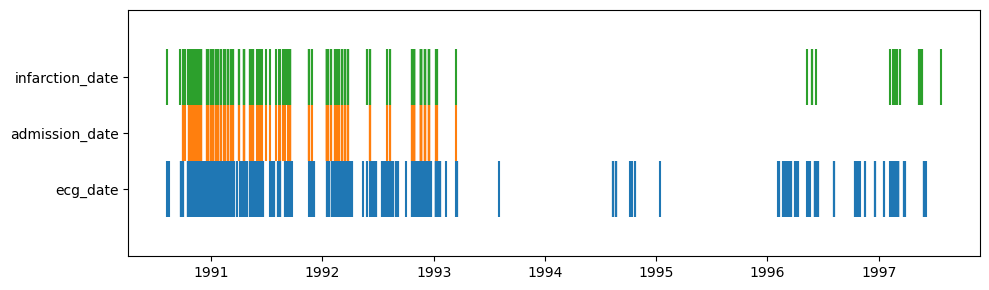

In [44]:
eventplot(records_df, ("ecg_date", "admission_date", "infarction_date"))

The last infarction date is later than the last ECG date?
Investigate this example further.

In [45]:
records_df.loc[records_df["infarction_date"].argmax()]

name                                                                              patient120/s0331lre
patient                                                                                    patient120
id                                                                                              s0331
ending                                                                                            lre
signals                                             [[-0.051, -0.9245, -0.8735, 0.488, 0.411, -0.8...
sig_len                                                                                        115200
Acute infarction (localization)                                                         antero-septal
Additional diagnoses                                                            Arterial hypertension
Additional medication                                                                             n/a
Admission date                                                                    

The patient already had an infarction in '91, so data are consistent.

Plot all events for a few patients with >1 ECG.

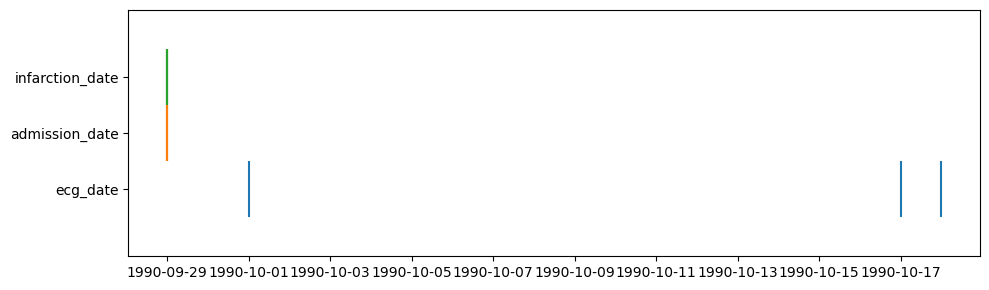

0   1990-10-01
1   1990-10-17
2   1990-10-18
Name: ecg_date, dtype: datetime64[ns]


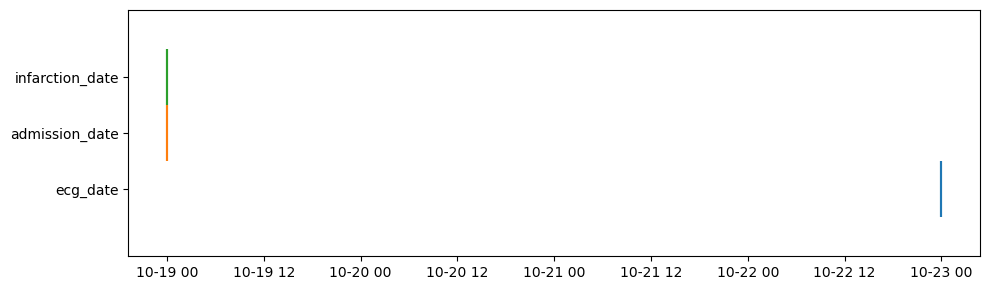

5   1990-10-23
6   1990-10-23
Name: ecg_date, dtype: datetime64[ns]


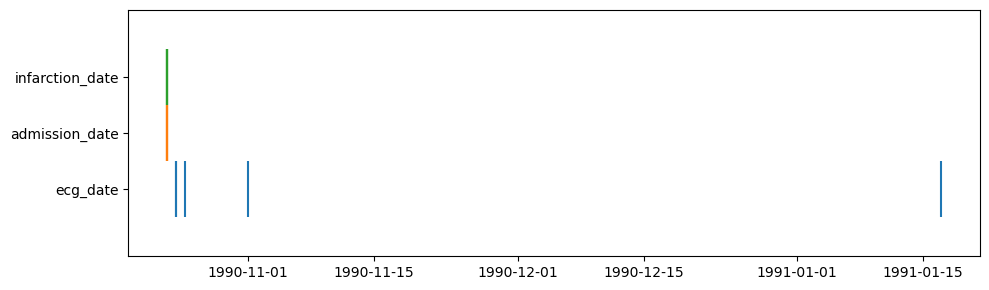

7    1990-10-24
8    1990-10-24
9    1990-10-25
10   1990-11-01
11   1991-01-17
Name: ecg_date, dtype: datetime64[ns]


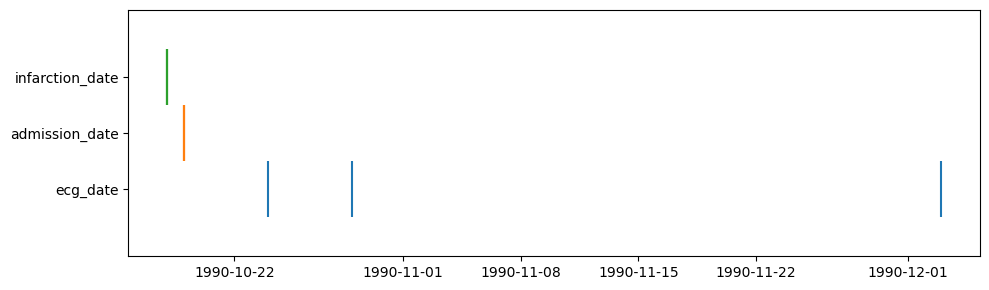

12   1990-10-24
13   1990-10-29
14   1990-12-03
Name: ecg_date, dtype: datetime64[ns]


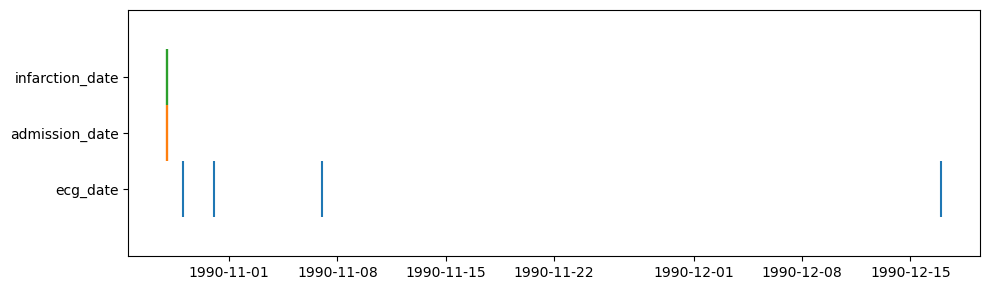

15   1990-10-29
16   1990-10-31
17   1990-11-07
18   1990-12-17
Name: ecg_date, dtype: datetime64[ns]


In [46]:
counter = 0
for patient, patient_df_ in records_df.groupby("patient"):
    if len(patient_df_) > 1:
        eventplot(patient_df_, ("ecg_date", "admission_date", "infarction_date"))
        print(patient_df_["ecg_date"])
        counter += 1
    if counter >= 5:
        break

Rename the diagnosis column and check if it is unique for all patients.

In [47]:
records_df.rename(columns={"Reason for admission": "diagnosis"}, inplace=True)
patient_df = records_df[["patient", "age", "sex", "smoker", "diagnosis"]].drop_duplicates()
patient_df["patient"].is_unique

True

Obtain some simple statistics of diagnoses by patient.

In [48]:
diagnosis_counts = patient_df["diagnosis"].value_counts()
diagnosis_counts

diagnosis
Myocardial infarction     148
Healthy control            52
n/a                        22
Cardiomyopathy             15
Bundle branch block        15
Dysrhythmia                14
Hypertrophy                 7
Valvular heart disease      6
Myocarditis                 4
Stable angina               2
Heart failure (NYHA 2)      1
Heart failure (NYHA 3)      1
Heart failure (NYHA 4)      1
Palpitation                 1
Unstable angina             1
Name: count, dtype: int64

**Task 4: what observations can be made from this distribution?**

_The dataset is clearly not balanced, nor is the distribution representative of the general population._

This is common in medical datasets.
Very often pathologic cases in general are over-represented due to sampling at the point-of-care,
even if healthy cases would be relatively easy to obtain.
More rare pathologies often have very little data even in large datasets,
so one needs to deal with imbalanced datasets.

Notes:

- Myocardial infarction is well represented.
- We have enough healthy controls, but clearly less than in the general population! Metrics will have to take this into account.
- Diseases with one patient cannot be trained and evaluated on different subjects.
- Diseases with only a handful of subjects will have very poor statistics, which makes them not very meaningful.

*Answer*:
- cut off around ~10 diagnosis for a good enough prediction

### Examples

A last very important step of exploration is to actually plot the signals for a few cases.

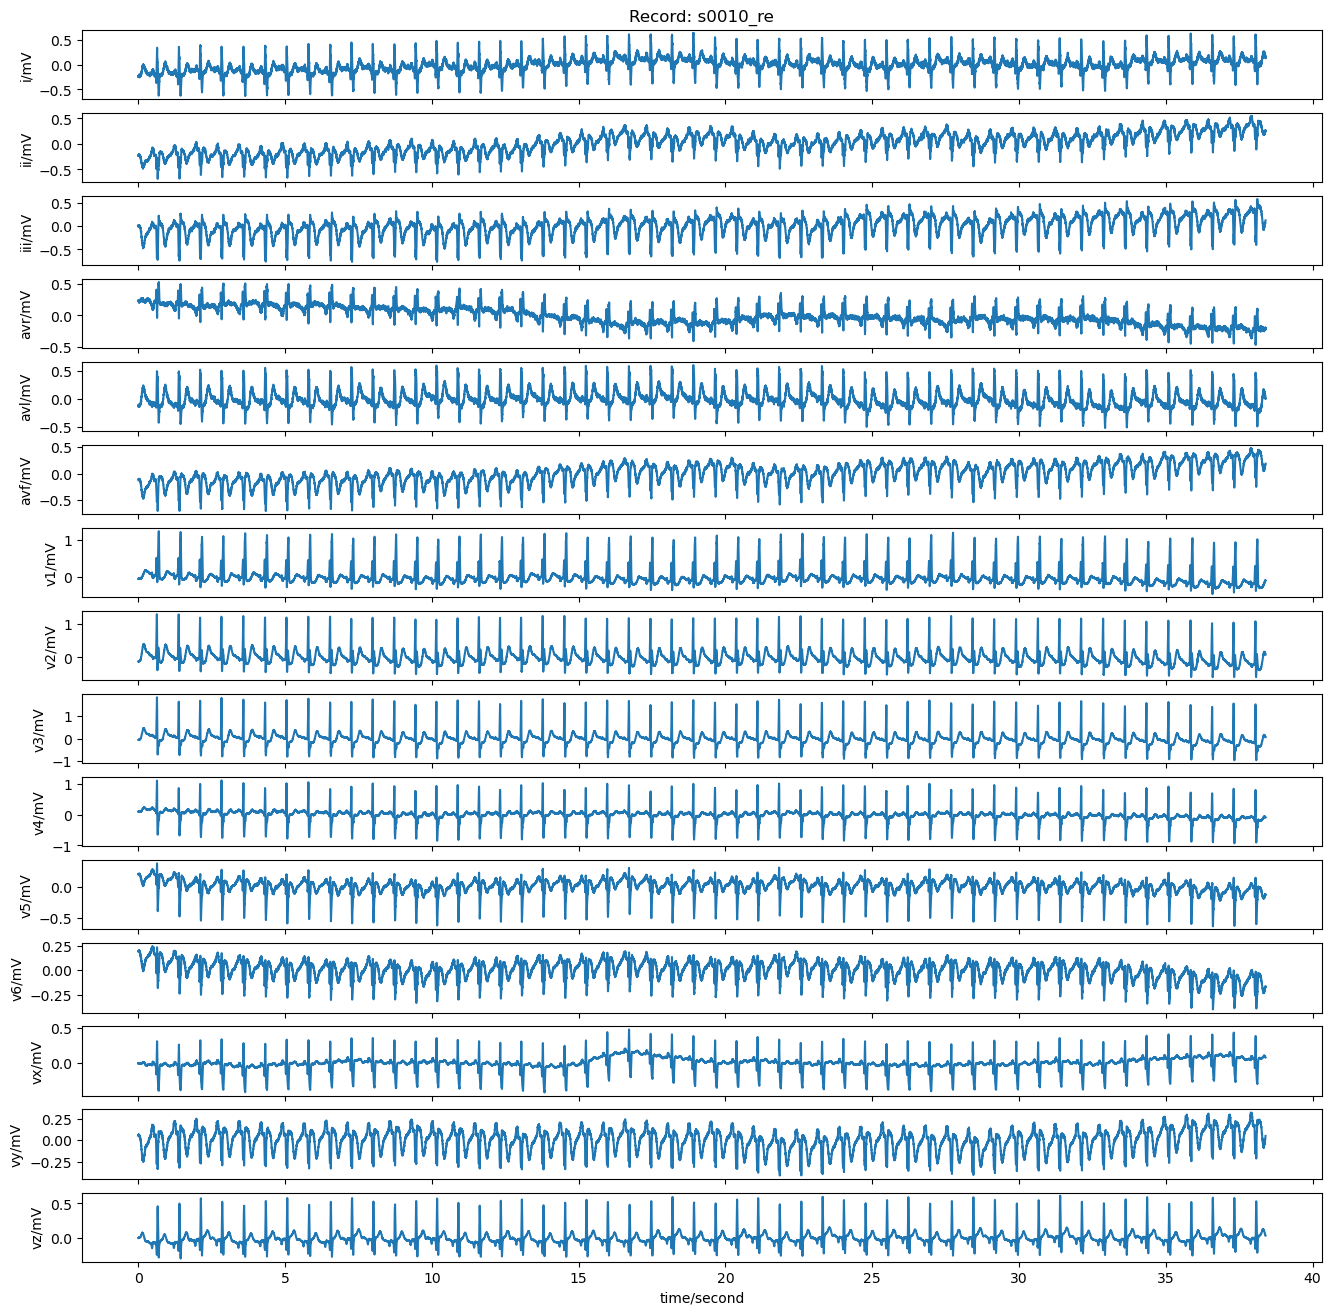

In [49]:
record = wfdb.rdrecord(record_name)
wfdb.plot.plot_wfdb(record, figsize=(16, 16))

Movement and respiration leads to different patterns.

Different heartbeat patterns for each lead can be observed.
It is also easy to note there can be baseline drifts
(usually attributed to patient movements).

Finally, store the lead names in a variable for future use.

In [50]:
lead_names = record.sig_name

## Splits

**Statistics for the test set**

Note: *formally* for the test set one is not allowed even to analyze statistics...
It is however sensible to ignore this constraint when data is limited,
or when special treatment of groups is needed (e.g. stratified sampling).

### Stratified sampling

Stratified sampling over some variables $x_1$, $x_2$, ...
means to perform splits randomly within each subgroup for fixed values (ranges) of the variables.
E.g. divide m/f, age groups 20-30, 30-40, ... and then perform splits randomly.

We will stratify splits over diagnoses to make sure we have some data for all of them
in all training and evaluation sets.
We could stratify folds also over age, sex and smoking habits.
We will refrain from this since the analysis should not be too sensitive to small fluctuations of these features among splits.

We could also stratify over the number of ECGs per patient.
This would help to keep the amount of data really balanced,
and would be very important for studies invloving follow-ups.

**Diagnoses to consider**

Some diagnoses have too little data for a meaningful evaluation.
The absolute minimum required is one sample for train, valid, and test set.
However, estimates with few samples tend not to be very meaningful.
Here we set the cutoff at at least 4 samples in a 34% test set, i.e. 12 in total.

In [51]:
labels = sorted(label for label in diagnosis_counts[diagnosis_counts > 12].index if label != "n/a")
labels

['Bundle branch block',
 'Cardiomyopathy',
 'Dysrhythmia',
 'Healthy control',
 'Myocardial infarction']

### Test set

First, define the patients with the selected diagnoses.

In [52]:
selected_patients = patient_df[patient_df["diagnosis"].isin(labels)].reset_index(drop=True)
selected_patients

,patient,age,sex,smoker,diagnosis
0,patient001,81.0,female,no,Myocardial infarction
1,patient002,58.0,female,yes,Myocardial infarction
2,patient003,63.0,male,yes,Myocardial infarction
3,patient004,69.0,male,no,Myocardial infarction
4,patient005,74.0,male,no,Myocardial infarction
...,...,...,...,...,...
239,patient290,60.0,male,n/a,Myocardial infarction
240,patient291,69.0,male,n/a,Myocardial infarction
241,patient292,66.0,male,n/a,Myocardial infarction
242,patient293,75.0,male,n/a,Myocardial infarction


Import the function to perform a dataset split from `scikit-learn`.
Choose a test size of 1/3 and leave the rest of the data for cross-validation.
Fix the seed of the random number generator, so that results are reproducible
and if there are issues with some specific data points they can be tracked down.
Then count the number of patients with each diagnosis in both sets
to make sure everything went right.

In [53]:
from sklearn.model_selection import train_test_split

patients_trainvalid, patients_test = train_test_split(
    selected_patients,
    test_size=0.34, # 1/3 is used for test(evaluation)
    stratify=selected_patients["diagnosis"],
    random_state=42, # fix random state
)

patients_trainvalid["diagnosis"].value_counts()

diagnosis
Myocardial infarction    98
Healthy control          34
Bundle branch block      10
Cardiomyopathy           10
Dysrhythmia               9
Name: count, dtype: int64

In [54]:
patients_test["diagnosis"].value_counts()

diagnosis
Myocardial infarction    50
Healthy control          18
Dysrhythmia               5
Bundle branch block       5
Cardiomyopathy            5
Name: count, dtype: int64

### Cross-validation

The nice tools of `scikit-learn` for folds do not work well with splits by patient...

The data is limited enough that it is worthwhile to use cross-validation.

In [55]:
N_FOLDS = 3

In [56]:
patients_trainvalid = patients_trainvalid.sort_values(by="patient")
patients_trainvalid["fold"] = -1
total = 0
for i, label in enumerate(labels):
    label_df = patients_trainvalid[patients_trainvalid["diagnosis"] == label]
    shuffled_df = label_df.sample(frac=1, random_state=i+1)
    for j in range(N_FOLDS):
        fold_indices = shuffled_df["patient"][j::N_FOLDS].index
        fold = (j + total) % N_FOLDS  # Rotate the number of the fold which gets residual elements
        patients_trainvalid.loc[fold_indices, "fold"] = fold
    total += len(shuffled_df)

In [57]:
for fold, fold_df in patients_trainvalid.groupby("fold"):
    print(f"Fold {fold}: {len(fold_df)}")
    print(fold_df["diagnosis"].value_counts())

Fold 0: 54
diagnosis
Myocardial infarction    33
Healthy control          11
Bundle branch block       4
Dysrhythmia               3
Cardiomyopathy            3
Name: count, dtype: int64
Fold 1: 54
diagnosis
Myocardial infarction    33
Healthy control          11
Cardiomyopathy            4
Dysrhythmia               3
Bundle branch block       3
Name: count, dtype: int64
Fold 2: 53
diagnosis
Myocardial infarction    32
Healthy control          12
Cardiomyopathy            3
Dysrhythmia               3
Bundle branch block       3
Name: count, dtype: int64


In [58]:
patient_fold_dict = {k: v for k, v in zip(patients_trainvalid["patient"], patients_trainvalid["fold"])}

**Important tip: save the cross validation folds so you do not have to recerate it again later on!**

```python
import pickle

# Save the patient_fold_dict to a file using pickle
with open('cross_validation_folds.pkl', 'wb') as file:
    pickle.dump(patient_fold_dict, file)
```

## Evaluation

To infer diagnoses from data, there are multiple categorical labels.
The problem can be formulated either as

- multi-class classification, if labels are mutually exclusive;
- multi-label classification, if multiple labels can occur at the same time.

Clearly the latter would be the case for the additional diagnoses,
but the dataset has been created with a single "reason for admission".

### Metrics

Track:

- the confusion matrix, since all other metrics can be computed from it
(if they do not involve a threshold);
- accuracy, as a check since it is the easiest to understand;
- balanced accuracy, the accuracy that would be calculated
if all classes had the same number of samples;
- Matthews correlation coefficient, as a single summary variable.

In [59]:
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    balanced_accuracy_score,
    matthews_corrcoef,
)
metrics = {
    "confusion_matrix": confusion_matrix,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "matthews_corrcoef": matthews_corrcoef,
}

Define a function for evaluation, given input
train/valid sets, features, label, model and metrics.

In [60]:
from typing import Protocol

class ScikitModel(Protocol):
    def fit(self, X, y, sample_weight=None): ...
    def predict(self, X): ...


from typing import Any, Callable, Dict, List, Tuple

def evaluate(
    Xy_train: pd.DataFrame,
    Xy_valid: pd.DataFrame,
    feature_columns: List[str],
    label_column: str,
    model: ScikitModel,
    metrics: Dict[str, Callable],
    class_weights: bool = False,
) -> List[Tuple[str, str, float]]:
    X_train = Xy_train[feature_columns]
    X_valid = Xy_valid[feature_columns]
    y_train = Xy_train[label_column]
    y_valid = Xy_valid[label_column]
    sample_weights = None
    if class_weights:
        class_weights_dict = 1 / Xy_train["diagnosis"].value_counts()
        sample_weights = Xy_train["diagnosis"].apply(lambda x: class_weights_dict[x])
    model.fit(X_train, y_train, sample_weights)
    results = []
    y_pred = model.predict(X_train)
    for k, v in metrics.items():
        results.append((k, "train", v(y_true=y_train, y_pred=y_pred)))
    y_pred = model.predict(X_valid)
    for k, v in metrics.items():
        results.append((k, "valid", v(y_true=y_valid, y_pred=y_pred)))
    return results

Define a function to perform evaluation for all folds,
and store the result in a dataframe.

In [61]:
def evaluate_folds(
    Xy: pd.DataFrame,
    *args,
    fold_column: str = "fold",
    **kwargs,
) -> pd.DataFrame:
    results = []
    folds = sorted(Xy[fold_column].unique())
    for fold in folds:
        bools = Xy[fold_column] == fold
        metric_values = evaluate(
            Xy_train=Xy[~bools], Xy_valid=Xy[bools], *args, **kwargs
        )
        for metric_name, split, value in metric_values:
            results.append((metric_name, fold, split, value))
    return pd.DataFrame(results, columns=("metric", "fold", "split", "value"))

### Dummy baselines

Get a copy of the train/valid data to run the baselines on,
since it will need to be modified.

Start with the dummy models which use no features.

In [62]:
Xy_trainvalid = patients_trainvalid.copy()  # Will need to be modified
feature_columns = [] # Dummy models uses no features
label_column = "diagnosis"

In [63]:
from sklearn.dummy import DummyClassifier
baselines = ["most_frequent", "stratified", "uniform"]
strategy_results = []
for strategy in baselines:
    model = DummyClassifier(strategy=strategy)
    strategy_result = evaluate_folds(
        Xy=Xy_trainvalid,
        feature_columns=feature_columns,
        label_column=label_column,
        model=model,
        metrics=metrics,
    )
    strategy_result["strategy"] = strategy
    strategy_results.append(strategy_result)
strategy_results = pd.concat(strategy_results)

Graphically display scores.

How many values does a confusion matrix have?
- 1 for each data point, i.e. 1 for each patient.

How many classes are there?
- The number of diagnoses(5) or ECGs. (Diagnosis: Myocardial infarction, Healthy control, 
Bundle branch block, Cardiomyopathy, Dysrhythmia)

In [64]:
strategy_scores = strategy_results[strategy_results["metric"] != "confusion_matrix"]
px.scatter(strategy_scores, facet_col="metric", facet_row="split", x="strategy", y="value", color="fold")

Observe that

- accuracy gets the highest score just above 20% with the "most frequent" or "popular" model;
- balanced accuracy remains around 20% with more or less fluctuations among folds for all models;
- MCC is around zero as expected for non-informative models.


### Advanced baselines

It is also interesting what is the performance obtained with models
which can only access the demographic information of patients.

Data needs some preprocessing, as some models will not work well with categorical features.

In [65]:
import numpy as np
def sex2float(x: str) -> float: # one-hot encoding
    if x == "female":
        return 0.0
    elif x == "male":
        return 1.0
    else:
        return np.nan
def smoker2float(x: str) -> float:
    if x == "no":
        return 0.0
    elif x == "yes":
        return 1.0
    else:
        return np.nan
Xy_trainvalid["sex_"] = Xy_trainvalid["sex"].apply(sex2float)
Xy_trainvalid["smoker_"] = Xy_trainvalid["smoker"].apply(smoker2float)

Explore/remember if some data have missing values.

In [66]:
print(Xy_trainvalid.isnull().sum())

patient       0
age           5
sex           0
smoker        0
diagnosis     0
fold          0
sex_          0
smoker_      48
dtype: int64


`smoker_` and `age` have some missing values. Because of that use...

- Represent the smoking habit as a one-hot vector,
indicating "yes" with (1, 0), "no" with (0, 1),
and unknown as (0, 0).
- Add a flag if age is a NaN to allow linear models to treat it as a separate case
(it gets its own coefficient), and also normalize age with a constant
to bring it to the same scale as the other variables.

Note that these additional columns "doubling" `smoker` and `age`
allow to learn how to treat missing values, as opposed to imputing them.

In [67]:
Xy_trainvalid["smoker_y"] = (Xy_trainvalid["smoker"] == "yes").astype(float)
Xy_trainvalid["smoker_n"] = (Xy_trainvalid["smoker"] == "no").astype(float)
Xy_trainvalid["age_nan"] = (Xy_trainvalid["age"].isna()).astype(float)
Xy_trainvalid["age_nonan"] = Xy_trainvalid["age"].fillna(-1.0) / 50.0

Evaluate a linear model with scaled and one-hot encoded features.

In [68]:
from sklearn.linear_model import LogisticRegression
lr_feature_columns = ["age_nonan", "age_nan", "sex_", "smoker_y", "smoker_n"]
lr_model = LogisticRegression()
lr_results = evaluate_folds(
    Xy=Xy_trainvalid,
    feature_columns=lr_feature_columns,
    label_column=label_column,
    model=lr_model,
    metrics=metrics,
)
lr_results["model"] = "lr"

Evaluate a tree-based ensemble model also on one-hot encoded features.

Tree models have a better baseline than logistic regression.

Which type of function can the logistic regression learn?
- linear

What can a decision tree learn?
- non-linear behaviour (very fast)

In [69]:
from sklearn.tree import ExtraTreeClassifier
et_feature_columns = ["age_nonan", "age_nan", "sex_", "smoker_y", "smoker_n"]
et_model = ExtraTreeClassifier()
et_results = evaluate_folds(
    Xy=Xy_trainvalid,
    feature_columns=et_feature_columns,
    label_column=label_column,
    model=et_model,
    metrics=metrics,
)
et_results["model"] = "et"

Evaluate a tree-based, gradient-boosting ensemble model which supports NaNs natively.

In [70]:
from lightgbm import LGBMClassifier
lgbm_feature_columns = ["age", "sex_", "smoker_"]
lgbm_model = LGBMClassifier()
lgbm_results = evaluate_folds(
    Xy=Xy_trainvalid,
    feature_columns=lgbm_feature_columns,
    label_column=label_column,
    model=lgbm_model,
    metrics=metrics,
)
lgbm_results["model"] = "lightgbm"

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000493 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 35
[LightGBM] [Info] Number of data points in the train set: 107, number of used features: 3
[LightGBM] [Info] Start training from score -2.881069
[LightGBM] [Info] Start training from score -2.726919
[LightGBM] [Info] Start training from score -2.881069
[LightGBM] [Info] Start training from score -1.537335
[LightGBM] [Info] Start training from score -0.498442
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

Collect all results and plot them.

In [71]:
results = pd.concat(
    [
        strategy_results.rename(columns={"strategy": "model"}),
        lr_results,
        et_results,
        lgbm_results,
    ]
)
scores = results[results["metric"] != "confusion_matrix"]

In [6]:
px.scatter(scores, facet_col="metric", facet_row="split", x="model", y="value", color="fold")

NameError: name 'px' is not defined

Smart baselines are much better than the dummy ones, as expected.
What is important in your problem is to understand if the difference is significant.

try to optimize accuracy

accuracy is not a good metric for imbalanced data

balanced accuracy = weighted average of recall obtained on each class
 
matthews correlation coefficient = correlation between the observed and predicted binary classifications

(Book: Pattern recognition and machine learning. Bishop, Christopher M. Springer, 2006.)

Observations:

- results are superior to the baselines, with logistic regression performing best (see validation results);
- increments are mostly larger than statistical fluctuations, depending on metric and model;
- the performance boost is mild in accuracy and most evident in MCC;
- performance in terms of balanced accuracy is still quite low.

The best performing model can be further inspected to determine
how it is taking decisions (hint: this is already very basic interpretability).

To analyze it, fix a fold / train model, and compute predictions for all features:
the space is small enough that it can be covered completely with a grid.

In [73]:
Xy_valid = Xy_trainvalid[Xy_trainvalid["fold"] == 0]
Xy_train = Xy_trainvalid[Xy_trainvalid["fold"] != 0]
X_train = Xy_train[lr_feature_columns]
y_train = Xy_train[label_column]
all_values = []
for sex in ("female", "male"):
    for smoking_habit in (True, False):
        for smoker in ("yes", "no"):
            new_df = Xy_valid.copy()
            new_df["smoker_y"] = float(smoking_habit & (smoker == "yes"))
            new_df["smoker_n"] = float(smoking_habit & (smoker == "no"))
            new_df["smoker"] = smoker if smoking_habit else "n/a"
            new_df["sex_"] = sex2float(sex)
            new_df["sex"] = sex
            all_values.append(new_df.drop_duplicates())
all_values = pd.concat(all_values)
all_values.sort_values("age_nonan", inplace=True)
all_values["age"] = all_values["age_nonan"] * 50

In [74]:
lr_model.fit(X_train, y_train)
probabilities = lr_model.predict_proba(all_values[lr_feature_columns])
all_values_class = []
for class_ in range(probabilities.shape[-1]):
    all_values["lr_pred"] = probabilities[:, class_]
    all_values["class"] = class_
    all_values_class.append(all_values.copy())
all_values_class_df = pd.concat(all_values_class)
px.line(all_values_class_df, x="age", y="lr_pred", facet_row="sex", facet_col="smoker", color="class", markers=True)

|Class|Description|
|:-:|:-|
| 0 | Bundle branch block |
| 1 | Cardiomyopathy |
| 2 | Dysrhythmia | 
| 3 | Healthy control |
| 4 | Myocardial infarction |

3 variables: age, sex, smoking habits
learning patterns

In [75]:
lr_model.classes_

array(['Bundle branch block', 'Cardiomyopathy', 'Dysrhythmia',
       'Healthy control', 'Myocardial infarction'], dtype=object)

The model has learned that

- subjects with undefined smoking habits below ~60 years of age
are less likely to have myocardial infarction;
- subjects with unspecified age are less likely to have myocardial infarction.

**Task 5: identify plausible reasons for these patterns and discuss their consequences for this ML model.**

A possible explanation for the observed pattern
is that ECGs of subjects with myocardial infarction
were acquired with a different process with respect to healthy controls,
which resulted in smoking habits that were not consistently recorded
for patients with infarction.

As a result, including smoking habits in the model is dangerous
because it may learn characteristics of data collection
which are not useful for actual diagnoses.

## Naive model

### Preprocessing

Display a signal from a single ECG lead (e.g. i)
in a time window of about 10 seconds to get a better feeling.

Power of 2 because of Fourier transform

In [76]:
frequency = 10 ** 3
window_length = 2 ** 13  # 8192 samples / 1000 Hz = 8.192 s ~ 10 s
a_record = records_df.iloc[42]
ecg_signals = a_record["signals"]
signal_i = ecg_signals[:window_length, 0]
px.line(signal_i)

The signal is quite noisy, with many samples carrying only noise information.
It can therefore be downsampled - humans can read it better and so will ML models.

one can use low-pass filter to remove noise!

To this end, we use the function `resample_poly` (polyphase resampling) from the `scipy` library.
These types of resampling functions create less artefacts than just skipping points or taking averages.

In [77]:
from scipy.signal import resample_poly
from functools import partial
downsample_factor = 2 ** 3
downsample = partial(resample_poly, up=1, down=downsample_factor)
ecg_downsampled_signals = downsample(ecg_signals)
downsampled_frequency = frequency / downsample_factor
downsampled_signal_i = ecg_downsampled_signals[: (window_length // downsample_factor), 0]
px.line(downsampled_signal_i)

Smooth to remove noise and downsample.

### Augmentation

To make use of all data, crop windows at several points in the original signal.
Increase variablity of training data by adding noise.

In [78]:
def augment(
    x: np.ndarray,
    start: float,
    window_length: int,
) -> np.ndarray:
    start_range = len(x) - window_length
    start_el = int(start * start_range)
    stop_el = start_el + window_length
    return x[start_el:stop_el, :]

In [79]:
n_augmentations = 3  # Intentionally kept low to avoid running out of RAM

In [80]:
X = []
for start_point in tqdm(np.linspace(0, 1, n_augmentations)):
    window_ds_signals = records_df["signals"].apply(
        lambda x: downsample(augment(x, start_point, window_length))
    )
    X.append(np.stack(window_ds_signals))
X = np.concatenate(X)

  0%|          | 0/3 [00:00<?, ?it/s]

In [81]:
naive_df = pd.DataFrame(X[:, :, 0]).reset_index(drop=True)
naive_df["diagnosis"] = np.tile(records_df["diagnosis"], n_augmentations)
naive_df["patient"] = np.tile(records_df["patient"], n_augmentations)

In [82]:
trainvalid_bools = naive_df["patient"].isin(patients_trainvalid["patient"])
naive_df_trainvalid = naive_df[trainvalid_bools].copy()
patient_fold_dict = {k: v for k, v in zip(patients_trainvalid["patient"], patients_trainvalid["fold"])}
naive_df_trainvalid["fold"] = naive_df_trainvalid["patient"].apply(lambda x: patient_fold_dict[x])
naive_df_trainvalid

,0,1,2,3,4,5,6,7,8,9,...,1017,1018,1019,1020,1021,1022,1023,diagnosis,patient,fold
3,0.164484,0.379542,0.419432,0.462957,0.480474,0.496244,0.500303,0.502282,0.503612,0.516708,...,0.332303,0.307039,0.297729,0.283678,0.290856,0.271449,0.322799,Myocardial infarction,patient002,2
12,-0.216244,-0.412892,-0.362060,-0.395558,-0.368473,-0.382975,-0.363465,-0.359945,-0.363197,-0.350910,...,-0.494986,-0.504816,-0.506366,-0.497593,-0.518504,-0.489179,-0.551927,Myocardial infarction,patient006,0
13,0.365414,0.719253,0.638422,0.674760,0.665855,0.675721,0.676354,0.691367,0.698922,0.693654,...,0.332349,0.357403,0.352751,0.330651,0.356246,0.321023,0.376785,Myocardial infarction,patient006,0
14,-0.366640,-0.708294,-0.624396,-0.675796,-0.628198,-0.616772,-0.513281,-0.241032,0.097345,0.053451,...,-0.536213,-0.515593,-0.519252,-0.493346,-0.508509,-0.473918,-0.560970,Myocardial infarction,patient006,0
15,0.017748,0.214870,0.617754,0.696428,0.480511,0.086274,-0.022726,0.081265,0.075527,0.083490,...,-0.065703,-0.055778,-0.070464,-0.055419,-0.076629,-0.092755,-0.115930,Myocardial infarction,patient007,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1636,-0.004217,-0.093553,-0.567419,-0.868080,-0.892054,-0.876160,-0.878330,-0.880654,-0.890419,-0.912418,...,-0.929580,-0.865572,-0.898579,-0.867030,-0.897261,-0.825750,-0.921655,Myocardial infarction,patient287,1
1637,0.450637,0.884939,0.788535,0.879429,0.835375,0.940647,0.893032,0.838859,0.903146,0.908789,...,0.945589,0.954999,0.963605,0.951985,0.987804,0.900803,1.016934,Myocardial infarction,patient287,1
1638,-0.604954,-1.170535,-1.023167,-1.093185,-1.039205,-1.059611,-1.022932,-1.021438,-0.993676,-0.974851,...,-1.106487,-1.095085,-1.115449,-1.089717,-1.129967,-1.053499,-1.183809,Cardiomyopathy,patient288,1
1639,0.091767,0.193466,0.186457,0.206749,0.183367,0.161989,0.167849,0.181178,0.169877,0.150320,...,-0.085790,-0.090188,-0.106958,-0.113629,-0.126512,-0.130412,-0.154160,Cardiomyopathy,patient289,0


Why not do feature normalization on this data?
- one can destroy the signal and their relationship

**A word of caution**

When working with signals, it is not a good idea to normalize data according to feature columns.
This may destroy (or make much more complicated) the relationships between consecutive data points.
If normalization is needed, perform it globally.

In [83]:
feature_columns = [i for i in range(1024)]

### Training and evaluation

Train and evaluate a logistic regression,
an extremely randomized trees, and a light gradient boosting machine model
on 101 1024-point windows for each ECG.

Note that evaluation is not performed by patient but by ECG,
so it is slightly different to the one of the advanced baselines.

In [84]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_results = evaluate_folds(
    Xy=naive_df_trainvalid,
    feature_columns=feature_columns,
    label_column=label_column,
    model=lr_model,
    metrics=metrics,
    class_weights=True,
)
lr_results["model"] = "lr"

/Users/choekyelnyungmartsang/opt/anaconda3/envs/MED/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/choekyelnyungmartsang/opt/anaconda3/envs/MED/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

In [85]:
from sklearn.tree import ExtraTreeClassifier
et_model = ExtraTreeClassifier()
et_results = evaluate_folds(
    Xy=naive_df_trainvalid,
    feature_columns=feature_columns,
    label_column=label_column,
    model=et_model,
    metrics=metrics,
    class_weights=True,
)
et_results["model"] = "et"

In [86]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier()
lgbm_results = evaluate_folds(
    Xy=naive_df_trainvalid,
    feature_columns=feature_columns,
    label_column=label_column,
    model=lgbm_model,
    metrics=metrics,
    class_weights=True,
)
lgbm_results["model"] = "lightgbm"

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.008903 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 211293
[LightGBM] [Info] Number of data points in the train set: 618, number of used features: 1024
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [87]:
results = pd.concat(
    [
        lr_results,
        et_results,
        lgbm_results,
    ]
)
scores = results[results["metric"] != "confusion_matrix"]
px.scatter(scores, facet_col="metric", facet_row="split", x="model", y="value", color="fold")

Why did we overfit the data so much?
- because we have a lot of data!
- curse of dimensionality
- we have a lot of features

*At least 10x data points than features!!*

Results are close to random.

**Task 6: explain why linear regression and tree-based models
perform close to random with raw input signals.**

The number of features to consider is large,
which means that even linear models have many parameters.
In turn, this leads to easily overfitting.
It is very difficult for models to learn patterns when the number of features is large
and they need to be aggregated to obtain something meaningful.

## Model on spectrogram

### Spectrogram example

Use the library `scipy` to compute the spectrogram.
API documentation can be found [here](https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.spectrogram.html).

Note that the choice of window size and hopping parameter are crucial.

In [88]:
from scipy.signal import spectrogram

Choose a window of roughly half a second, and frequent hops.
"Hann" window is an option frequently used for ECGs.

In [89]:
nperseg = 2 ** 6  # 64 samples at 125 Hz give about 1/2 a second
nhop = 2 ** 2  # Steps are 4 samples at 125 Hz, 0.03s (similar to ECG paper)
noverlap = nperseg - nhop
nfft = 2 ** 7
window = "hann"

Compute and plot the log of the spectrogram.

(65, 241)


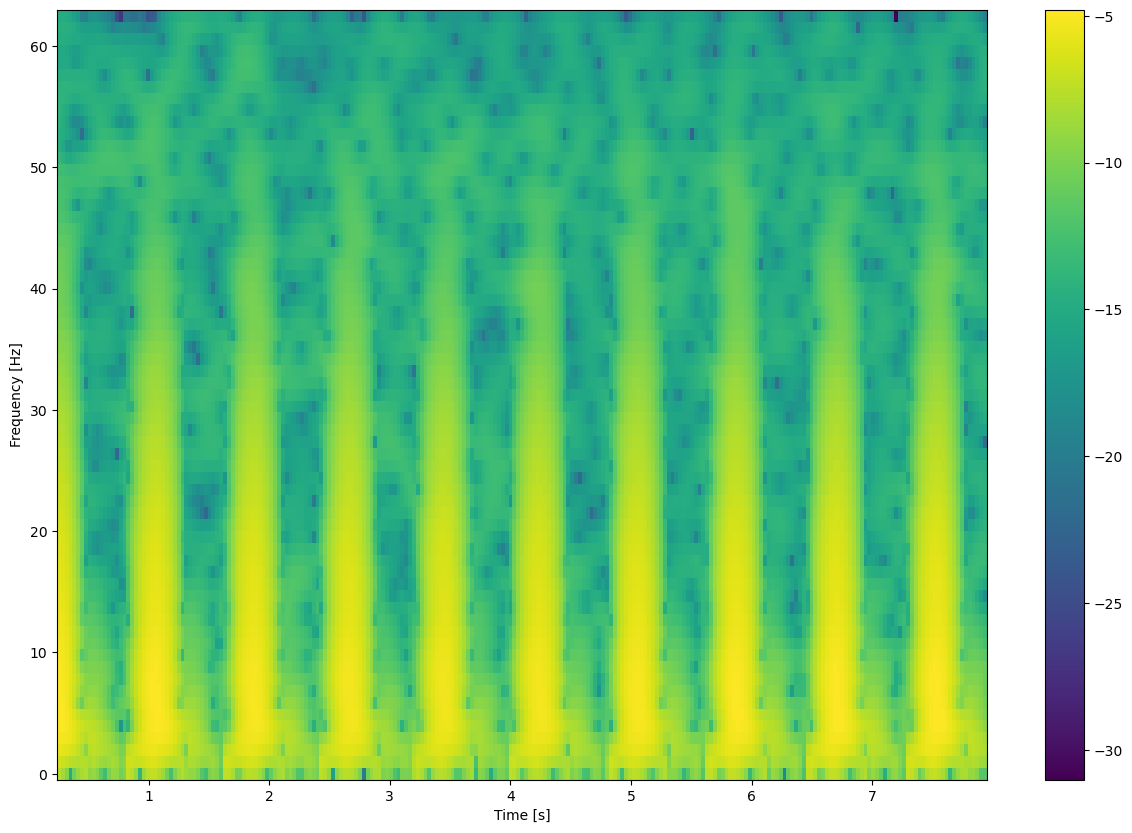

In [90]:
f_spectrogram, t_spectrogram, a_spectrogram = spectrogram(
    downsampled_signal_i,
    nperseg=nperseg,
    noverlap=noverlap,
    nfft=nfft,
    window=window,
    fs=downsampled_frequency,
)
print(a_spectrogram.shape)
plt.figure(figsize=(15, 10))
plt.pcolormesh(t_spectrogram, f_spectrogram, np.log(a_spectrogram))
plt.colorbar()
plt.ylabel('Frequency [Hz]')
plt.xlabel('Time [s]')
plt.show()

Heartbeats are fairly visible, and span up to different frequencies.
P and T waves are confined to the lower part of the spectrum.


### Spectrogram features

To limit the runtime,
only compute the spectrogram of lead "i";
work from the "augmented" (windowed) data directly.

In [91]:
# Takes ~2 mins
_, _, spectrogram_ = spectrogram(
    X[:, :, 0],
    nperseg=nperseg,
    noverlap=noverlap,
    window=window,
    nfft=nfft,
    fs=downsampled_frequency,
)
spectrogram_.shape

(1647, 65, 241)

Take the log of the spectrogram, and replace potential $\log(0)$
with the logarithm of a small number.

In [92]:
log_spectrogram = np.log(spectrogram_)
log_eps = np.log(np.finfo(float).eps)
log_spectrogram[~(log_spectrogram > log_eps)] = log_eps

Compute summary statistics (moments) of the distribution of the power spectrum across time.
This can contain information for example about the QRS complex, P and T waves.

Note that "skew" computes the imbalance of a distribution to the left or right of the mean;
"kurtosis" computes how heavy the tails of a distribution are with respect to a gaussian.

In [93]:
from scipy.stats import skew, kurtosis
spectrogram_stats = [
    log_spectrogram.mean(axis=-1),
    log_spectrogram.std(axis=-1),
    skew(log_spectrogram, axis=-1),
    kurtosis(log_spectrogram, axis=-1),
]

Concatenate the means, stds, skews and kurtoses;
then store them in a dataframe with label and patient information.

In [94]:
features = np.concatenate(spectrogram_stats, axis=-1)

In [95]:
features_df = pd.DataFrame(features).reset_index(drop=True)
features_df["diagnosis"] = naive_df["diagnosis"]
features_df["patient"] = naive_df["patient"]
features_df

,0,1,2,3,4,5,6,7,8,9,...,252,253,254,255,256,257,258,259,diagnosis,patient
0,-9.278524,-7.551665,-7.214662,-7.393481,-7.512443,-7.789762,-7.853667,-7.595058,-7.940387,-8.689128,...,0.737921,0.696432,0.752325,1.959195,4.561895,2.644297,-0.050048,3.906749,Myocardial infarction,patient001
1,-9.416150,-7.339672,-6.858190,-6.828786,-7.042577,-7.169850,-7.389389,-7.252235,-7.378378,-8.066261,...,-0.493972,-0.066813,1.846547,1.633886,2.189590,1.936847,0.578355,6.731053,Myocardial infarction,patient001
2,-8.934685,-7.143524,-6.822849,-7.019354,-6.916363,-7.183172,-7.349389,-7.264378,-7.673443,-8.319898,...,9.161646,0.687560,3.401491,0.792041,0.513390,2.648962,0.673939,1.777113,Myocardial infarction,patient001
3,-10.603264,-8.592349,-8.334849,-8.168629,-8.031987,-8.174881,-8.963443,-9.330109,-9.005434,-9.003671,...,0.664679,0.212841,-0.485966,-0.532266,-0.490046,0.243277,-0.471863,3.185180,Myocardial infarction,patient002
4,-10.553234,-8.837712,-8.164115,-7.919194,-7.922306,-8.143884,-8.477406,-8.634225,-9.061458,-9.543254,...,2.375032,3.485998,0.676878,2.065164,1.209044,1.180383,0.379489,4.692600,Myocardial infarction,patient003
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1642,-8.300781,-6.492653,-6.078214,-6.072680,-5.869072,-5.808360,-5.907537,-6.320533,-6.402624,-6.519833,...,-0.278247,0.008401,0.143000,0.156357,1.567446,0.166053,0.147830,1.742125,Myocardial infarction,patient292
1643,-7.719617,-5.928425,-5.643439,-6.045849,-6.027363,-6.636495,-6.698912,-6.597128,-6.755949,-7.556888,...,-0.339843,0.615753,-0.399910,-0.612616,0.798655,1.776099,1.420679,1.214364,Myocardial infarction,patient292
1644,-10.388926,-8.406785,-8.070647,-8.404131,-8.895603,-8.957041,-9.440456,-9.752565,-10.395232,-11.000175,...,-1.307807,-0.933858,0.725400,-0.828222,-0.887030,-0.753134,0.398504,1.235388,Myocardial infarction,patient293
1645,-8.810420,-6.986144,-6.700536,-7.166190,-7.789039,-7.538708,-7.812013,-8.104157,-8.471313,-8.809728,...,-0.231775,0.617671,-0.447564,-0.276078,1.015694,-0.159441,-0.530687,1.883308,Myocardial infarction,patient293


### Training and evaluation

The dataframe of power spectrum distributions has the same row structure
as the dataframe of naive signal features;
take the train/valid versus test split as well as the fold information from there.
Also define feature column names, which are just a progressive number
along the concatenated feature direction.

In [96]:
features_df_trainvalid = features_df[trainvalid_bools].copy()
features_df_trainvalid["fold"] = naive_df_trainvalid["fold"]

In [97]:
feature_columns = [i for i in range(features.shape[-1])]

Train and validate the three usual types of model, and display the scores.

In [98]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_results = evaluate_folds(
    Xy=features_df_trainvalid,
    feature_columns=feature_columns,
    label_column=label_column,
    model=lr_model,
    metrics=metrics,
    class_weights=True,
)
lr_results["model"] = "lr"

/Users/choekyelnyungmartsang/opt/anaconda3/envs/MED/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

/Users/choekyelnyungmartsang/opt/anaconda3/envs/MED/lib/python3.9/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_

In [99]:
from sklearn.tree import ExtraTreeClassifier
et_model = ExtraTreeClassifier()
et_results = evaluate_folds(
    Xy=features_df_trainvalid,
    feature_columns=feature_columns,
    label_column=label_column,
    model=et_model,
    metrics=metrics,
    class_weights=True,
)
et_results["model"] = "et"

In [100]:
from lightgbm import LGBMClassifier
lgbm_model = LGBMClassifier()
lgbm_results = evaluate_folds(
    Xy=features_df_trainvalid,
    feature_columns=feature_columns,
    label_column=label_column,
    model=lgbm_model,
    metrics=metrics,
    class_weights=True,
)
lgbm_results["model"] = "lightgbm"

[LightGBM] [Warning] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002795 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 53773
[LightGBM] [Info] Number of data points in the train set: 618, number of used features: 260
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best

In [101]:
results = pd.concat(
    [
        lr_results,
        et_results,
        lgbm_results,
    ]
)
scores = results[results["metric"] != "confusion_matrix"]
px.scatter(scores, facet_col="metric", facet_row="split", x="model", y="value", color="fold")

Scores are far from good, but definitely higher than zero even considering statistical fluctuations.

To gain some more insight, look at the confusion matrices by fold and model,
both raw and normalized by number of samples.

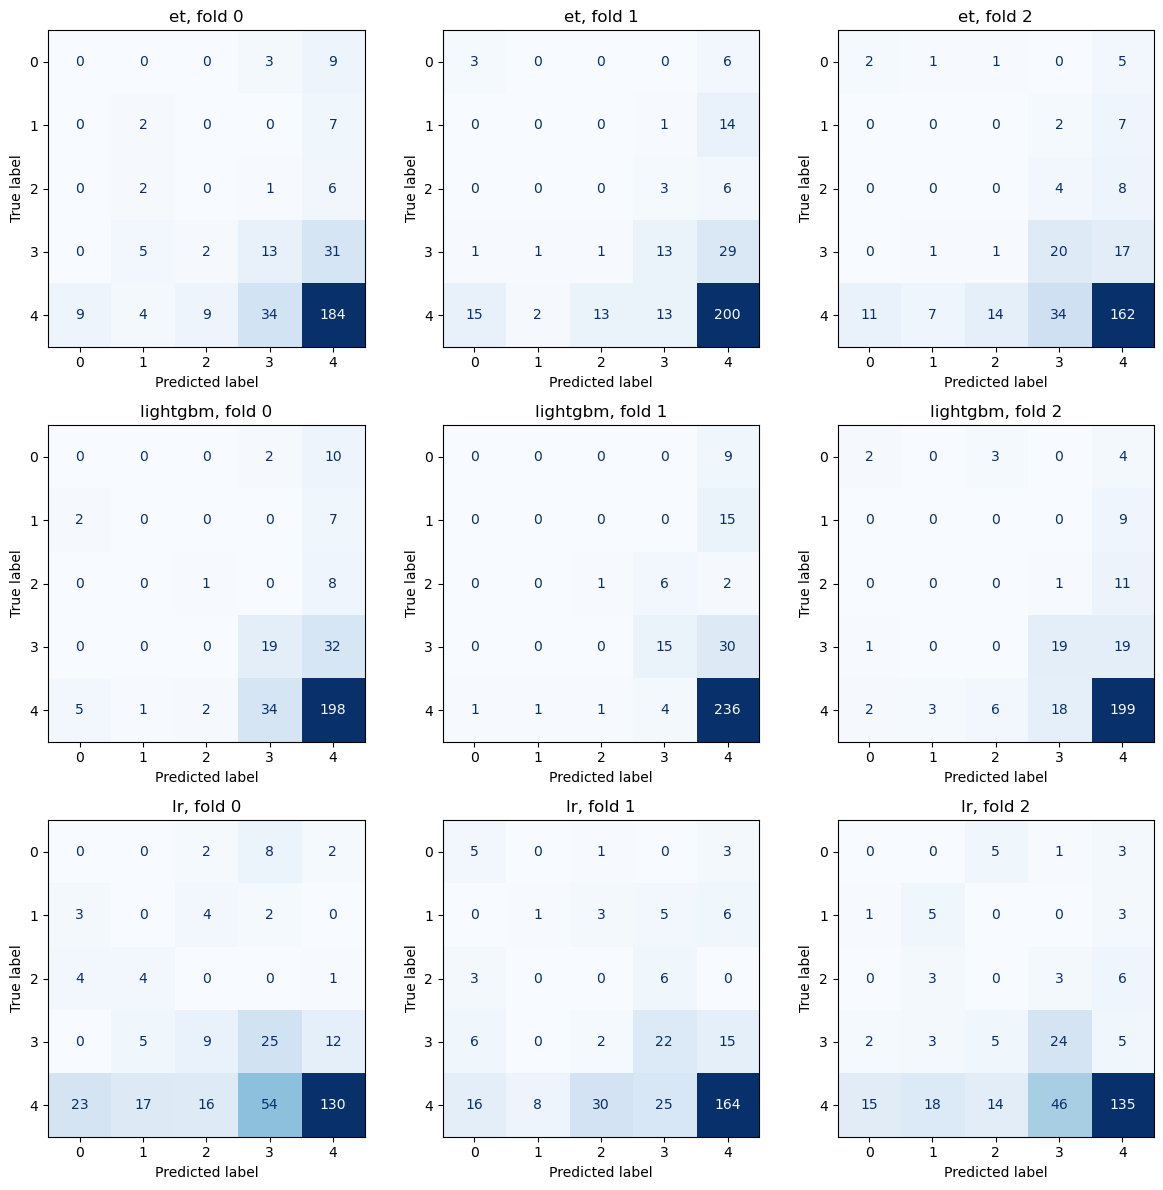

In [102]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axs = plt.subplots(figsize=(12, 12), nrows=3, ncols=3)
for i, model in enumerate(sorted(results["model"].unique())):
    for j, fold in enumerate(sorted(results["fold"].unique())):
        result_bools = (
            (results["metric"] == "confusion_matrix") &
            (results["split"] == "valid") &
            (results["model"] == model) &
            (results["fold"] == fold)
        )
        cm = results[result_bools].iloc[0]["value"]
        cmd = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            # display_labels=labels,  # Names are too long to be displayed
        )
        cmd.plot(ax=axs[i, j], cmap="Blues", colorbar=False)
        axs[i, j].set_title(f"{model}, fold {fold}")
fig.tight_layout()
plt.show()

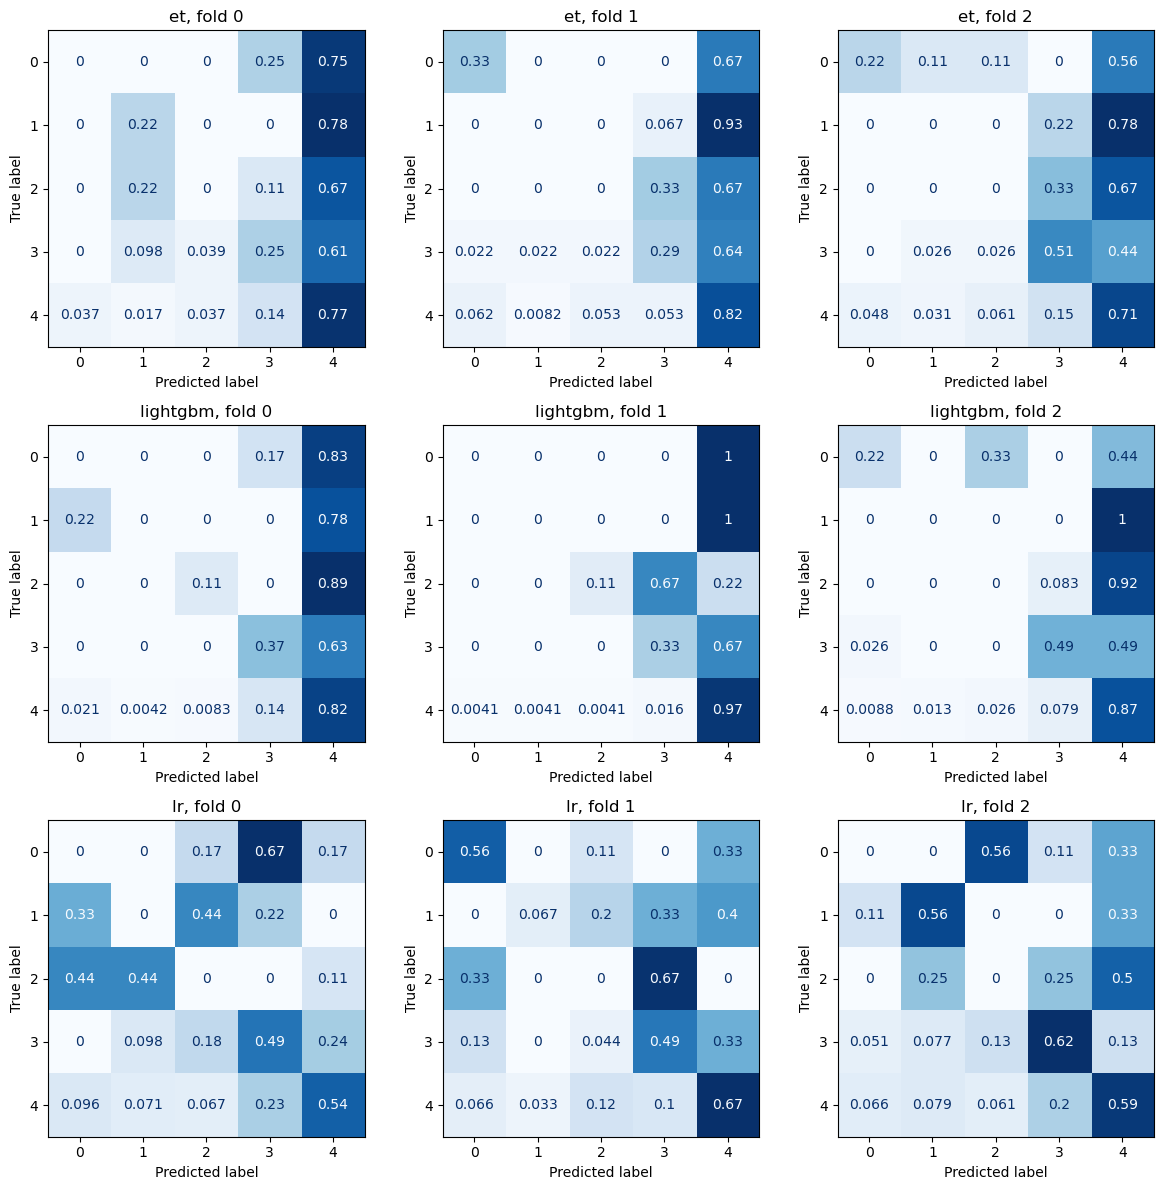

In [103]:
from sklearn.metrics import ConfusionMatrixDisplay
fig, axs = plt.subplots(figsize=(12, 12), nrows=3, ncols=3)
for i, model in enumerate(sorted(results["model"].unique())):
    for j, fold in enumerate(sorted(results["fold"].unique())):
        result_bools = (
            (results["metric"] == "confusion_matrix") &
            (results["split"] == "valid") &
            (results["model"] == model) &
            (results["fold"] == fold)
        )
        cm = results[result_bools].iloc[0]["value"]
        cm = cm / cm.sum(axis=1, keepdims=True)
        cmd = ConfusionMatrixDisplay(
            confusion_matrix=cm,
            # display_labels=labels,  # Names are too long to be displayed
        )
        cmd.plot(ax=axs[i, j], cmap="Blues", colorbar=False)
        axs[i, j].set_title(f"{model}, fold {fold}")
fig.tight_layout()
plt.show()

The performance does not look too good.
However notice:

- the vast majority of samples, those affected by Miocardial Infarction, is classified correctly;
- when looking at normalized scores, the 2 x 2 matrix in the bottom-right corner has a heavy diagonal
where also a significant fraction of healthy controls is classified correctly for LightGBM.

Results with this simple type of feature engineering are better than random,
but unsatisfactory: the problem is really not so easy!

## Deep learning

Deep Learning (DL) promises to skip the feature engineering part,
learning the right representation of data from data itself.

Use the `tensorflow` framework for this part.

In [104]:
import tensorflow as tf

### Data generation

First, to generate data effectively, create a dataframe with whole downsampled signals,
without any windowing.

In [105]:
trainvalid_bools = records_df["patient"].isin(patients_trainvalid["patient"])
records_trainvalid = records_df[trainvalid_bools].copy()
records_trainvalid["fold"] = records_trainvalid["patient"].apply(lambda x: patient_fold_dict[x])
records_trainvalid["ds_signals"] = records_trainvalid["signals"].apply(downsample)

Fix the validation fold for now;
DL models are heavy to train and here there is no time for cross-validation.

In [106]:
valid_fold = 2
valid_bools = records_trainvalid["fold"] == valid_fold
records_train = records_trainvalid[~valid_bools]
records_valid = records_trainvalid[valid_bools]

Create a generator object which produces windows of downsampled signals
at random positions and in shuffled order for training,
together with labels and sample weights for training.

Note that for validation during the training process only the first window is used.

In [107]:
class Generator():
    def __init__(
        self,
        signals: pd.Series,
        labels: pd.Series,
        window_length: int,
        train: bool = False, # True = the data generator shuffles the indices
        random_seed: int = 42,
        class_weights_power: float = -1.0,
    ):
        if len(signals) != len(labels):
            raise ValueError("`signals` and `labels` should have the same length")
        self.signals = signals
        self.labels = labels
        self.window_length = window_length
        self.diagnosis2class = {x: i for i, x in enumerate(sorted(labels.unique()))}
        self.class2diagnosis = {v: k for k, v in self.diagnosis2class.items()}
        self.class_weights = labels.value_counts() ** class_weights_power
        self.train = train
        self.rng = np.random.default_rng(random_seed)

    def __call__(self):
        indices = np.arange(len(self.labels))
        if self.train:
            self.rng.shuffle(indices)
        for i in indices:
            signal = self.signals.iloc[i]
            label = self.labels.iloc[i]
            start = 0
            if self.train:
                start = self.rng.integers(signal.shape[0] - self.window_length)
            stop = start + self.window_length
            x = np.expand_dims(signal[start:stop, :], axis=-1)
            y = np.zeros(shape=(len(self.diagnosis2class), )) # one-hot encoding
            y[self.diagnosis2class[label]] = 1.0
            w = self.class_weights[label]
            yield x, y, w # iterator for training

    def signature(self):
        return (
            tf.TensorSpec(shape=(self.window_length, self.signals.iloc[0].shape[-1], 1), dtype=float),
            tf.TensorSpec(shape=(len(self.diagnosis2class),), dtype=float),
            tf.TensorSpec(shape=(), dtype=float),
        )

Input: ECG signal data (signals) and diagnosis labels (labels)

Data Yielding:
Inside the `__call__` method, for each iteration, it selects a random window of window_length from an ECG signal, one-hot encodes the label, and assigns class weights. This data is then yielded as x, y, and w (features, labels, and weights) for model training.

Create the generators of training and validation examples, and test them.

In [108]:
train_generator_class = Generator(
    signals=records_train["ds_signals"],
    labels=records_train["diagnosis"],
    window_length=window_length // downsample_factor,
    train=True,
)
valid_generator_class = Generator(
    signals=records_valid["ds_signals"],
    labels=records_valid["diagnosis"],
    window_length=window_length // downsample_factor,
)
train_generator = train_generator_class()
valid_generator = valid_generator_class()

In [109]:
el = next(train_generator)
el[0].shape, el[1].shape, el[2].shape

((1024, 15, 1), (5,), ())

for every object, try to use the element as inteded. Just to make sure it's working.

Create `tensorflow.data.Dataset` objects which automatically batch and prefetch the data.

TensorFlow datasets are efficiently processed by deep learning models, and this step prepares the data for training and validation.

In [110]:
dataset_train = tf.data.Dataset.from_generator(
    generator=train_generator_class,
    output_signature=train_generator_class.signature(),
)
dataset_valid = tf.data.Dataset.from_generator(
    generator=valid_generator_class,
    output_signature=valid_generator_class.signature(),
)

2023-09-09 13:47:10.336718: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1 Pro
2023-09-09 13:47:10.336789: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 16.00 GB
2023-09-09 13:47:10.336800: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 5.33 GB
2023-09-09 13:47:10.337098: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:303] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-09-09 13:47:10.337160: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:269] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Overall, this code is a crucial component when working with deep learning models because it efficiently prepares and feeds the data to the model during training and validation. It ensures that the data is randomized, properly formatted, and that class imbalances are addressed through class weights. This data generator is versatile and can be used in various deep learning architectures, including CNNs and RNNs, where handling sequences or windows of data is common practice.

In [111]:
batch_size = 64
dataset_train = dataset_train.batch(batch_size=batch_size)
dataset_valid = dataset_valid.batch(batch_size=batch_size)
dataset_train = dataset_train.prefetch(tf.data.AUTOTUNE)
dataset_valid = dataset_valid.prefetch(tf.data.AUTOTUNE)

Batching and Prefetching:

After creating the TensorFlow datasets (dataset_train and dataset_valid) using your data generator, the code batches the data into mini-batches (each with batch_size samples) using dataset_train.batch() and dataset_valid.batch(). Batching is a common practice in deep learning to process data in smaller chunks during training.

### Model

**Task 7: which types of artificial neural networks are well-suited for this problem?**

Start with defining global pooling layers.
For a better performance, take both the maximum and the average as features.

*Answer:*
- Convolutional neural networks (CNNs) are well suited for this problem.
- Recurrent neural networks (RNNs) are also well suited for this problem. (LSTM, GRU)

Why not multilayer perceptron (MLP)?
- MLPs are not well suited for this problem because they are not able to capture the temporal dependencies in the data.

CNNs are faster than RNNs, so we will use them.

Tricks:
- Dialated convolution
- Skip connections (helpful for gradient propagation)

In [112]:
"""These layers perform pooling along a specific axis (axis=-3) of the input tensor. These custom layers will be used later in the model."""
class MaxPoolAxis(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.math.reduce_max(inputs, axis=-3, keepdims=False)
class AvgPoolAxis(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.math.reduce_mean(inputs, axis=-3, keepdims=False)

Define a network with blocks of convolutions,
which need to be 2D to avoid mixing ECG leads as different filters.
After each block, add the average and maximum global pools to the features
that will be used by the final dense layers.

In [113]:
N_FILTERS = 32 # number of filters for the convolutional layers
N_LAYERS = 8 # number of convolutional layers
KERNEL_SIZE = (2, 1) # (time, channels) size of the convolutional layers
STRIDES = (2, 1) # strides of the convolutional layers
DROPOUT = 0.5 # dropout rate

In [114]:
inputs = tf.keras.layers.Input(shape=(None, 15, 1), batch_size=None, dtype=tf.float32) # handles input sequence of length with 15 channels(features) and a single time step. The batch size is None to allow for variable batch sizes during training.
result = inputs
results = []
for filters in [N_FILTERS for _ in range(N_LAYERS)]:
    result = tf.keras.layers.Conv2D(
        filters=filters, kernel_size=KERNEL_SIZE, strides=STRIDES, activation="relu"
    )(result)
    avgpool = AvgPoolAxis()(result)
    maxpool = MaxPoolAxis()(result)
    concatpool = tf.keras.layers.Concatenate()([avgpool, maxpool])
    results.append(concatpool)
    result = tf.keras.layers.LayerNormalization(center=False, scale=False)(result)
result = tf.keras.layers.Flatten()(tf.keras.layers.Concatenate()(results))
result = tf.keras.layers.Dropout(DROPOUT)(result)
result = tf.keras.layers.LayerNormalization(center=False, scale=False)(result)
result = tf.keras.layers.Dense(2 * N_FILTERS, activation="relu")(result)
result = tf.keras.layers.Dropout(DROPOUT)(result)
result = tf.keras.layers.LayerNormalization(center=False, scale=False)(result)
outputs = tf.keras.layers.Dense(len(labels), activation="linear")(result) # linear activation for regression
model = tf.keras.Model(inputs=inputs, outputs=outputs, name="Model")
print(model.summary())

Model: "Model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, None, 15, 1)]        0         []                            
                                                                                                  
 conv2d (Conv2D)             (None, None, 15, 32)         96        ['input_1[0][0]']             
                                                                                                  
 layer_normalization (Layer  (None, None, 15, 32)         0         ['conv2d[0][0]']              
 Normalization)                                                                                   
                                                                                                  
 conv2d_1 (Conv2D)           (None, None, 15, 32)         2080      ['layer_normalization[0][0

Try running the model on a sample and `check the result` makes sense.

In [115]:
model(np.expand_dims(el[0], axis=0))

<tf.Tensor: shape=(1, 5), dtype=float32, numpy=
array([[-0.02395099,  1.6210599 ,  2.0547242 ,  0.27337867,  3.283591  ]],
      dtype=float32)>

### Metrics

It is often helpful to train models at the level of logits
for numerical stability.
`tensorflow` does not provide metrics that are computed from logits,
but luckily there is an easy hack.

Track categorical accuracy and MCC, and this will also enable to obtain
balanced accuracy as a weighted version of standard accuracy.
During training these meatrics are computed per ECG and not per patient.

In [116]:
import tensorflow_addons as tfa

"""Used to specify whether the metrics should operate on logits or probabilities."""
class FromLogitsMixin:
    #  If from_logits is set to True, the metric will work with logits, and if it's False, it will work with probabilities.
    def __init__(self, from_logits=False, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.from_logits = from_logits

    def update_state(self, y_true, y_pred, sample_weight=None):
        if self.from_logits:
            y_pred = tf.nn.softmax(y_pred)
        return super().update_state(y_true, y_pred, sample_weight)

"""These custom classes provide the option to handle logits or probabilities during metric computation."""
class CategoricalAccuracy(FromLogitsMixin, tf.metrics.CategoricalAccuracy):
    ...

class MatthewsCorrelationCoefficient(FromLogitsMixin, tfa.metrics.MatthewsCorrelationCoefficient):
    ...

# Used to evaluate the model's performance
metrics = [
    CategoricalAccuracy(),
    MatthewsCorrelationCoefficient(num_classes=len(labels)),
]
# Used for weighted evaluation
weighted_metrics = [
    CategoricalAccuracy(),
]

/Users/choekyelnyungmartsang/opt/anaconda3/envs/MED/lib/python3.9/site-packages/tensorflow_addons/utils/tfa_eol_msg.py:23: UserWarning:



TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 




### Training

Use the Adam optimizer and categorical crossentropy loss.

In [117]:
optimizer = tf.optimizers.Adam(learning_rate=1e-4) # optimizer
# optimizer = tf.keras.optimizers.legacy.Adam(learning_rate=1e-4) # optimizer for Mac M1/M2
loss = tf.keras.losses.CategoricalCrossentropy(from_logits=True) # model output is in form of logits.
model.compile(optimizer=optimizer, loss=loss, metrics=metrics, weighted_metrics=weighted_metrics)

Check the results of the model before training (this is a useful debug step).

In [118]:
model.evaluate(dataset_valid)

2023-09-09 13:47:14.566703: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:114] Plugin optimizer for device_type GPU is enabled.


      2/Unknown - 3s 259ms/step - loss: 0.1110 - categorical_accuracy: 0.0505 - MatthewsCorrelationCoefficient: -0.0520 - weighted_categorical_accuracy: 0.0772

2023-09-09 13:47:17.534263: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 11905918653883393022
2023-09-09 13:47:17.534277: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 6042300135079503568
2023-09-09 13:47:17.534283: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 8776352994549950904
2023-09-09 13:47:17.534286: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 11688458810348306708
2023-09-09 13:47:17.534296: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 9553712347367566866
2023-09-09 13:47:17.534310: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 13707393916920946751
2023-09-09 13:47:17.534332: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv 

2/2 [==============================] - 4s 805ms/step - loss: 0.1110 - categorical_accuracy: 0.0505 - MatthewsCorrelationCoefficient: -0.0520 - weighted_categorical_accuracy: 0.0772


[0.11104811728000641,
 0.05050504952669144,
 -0.05196433886885643,
 0.07719298452138901]

In [119]:
model.evaluate(dataset_train)

4/4 [==============================] - 0s 138ms/step - loss: 0.0543 - categorical_accuracy: 0.0841 - MatthewsCorrelationCoefficient: 0.0051 - weighted_categorical_accuracy: 0.1887


2023-09-09 13:47:18.602051: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 11688458810348306708
2023-09-09 13:47:18.602069: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 11905918653883393022
2023-09-09 13:47:18.602077: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 870485031098742512
2023-09-09 13:47:18.602090: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 16180142648655785588
2023-09-09 13:47:18.602096: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 13707393916920946751
2023-09-09 13:47:18.602101: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv item cancelled. Key hash: 8661551411893741521
2023-09-09 13:47:18.602105: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous recv 

[0.0543224923312664,
 0.08411215245723724,
 0.005126771051436663,
 0.18866458535194397]

Already observe that metric values for an untrained model fluctuate widely between training and validation set!

Run the training.

Notes:

- An epoch corresponds to passing through a single window for each ECG, not really through all data.
- For the same reason, the training data (and the corresponding loss!) is different each epoch;
this has a strong regularizing effect, but causes loss and metrics to fluctuate significantly.

Early Stopping: Implement early stopping, which monitors the validation loss or another relevant metric and stops training when it stops improving. This prevents overfitting and can lead to a lower number of epochs.

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping
# patience parameter determines how many epochs the model can continue without improvement before stopping.
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=50,
    restore_best_weights=True
)

In [ ]:
count_epochs = 1000 # epochs=1000
history = model.fit(dataset_train, validation_data=dataset_valid, epochs=count_epochs, callbacks=[early_stopping])

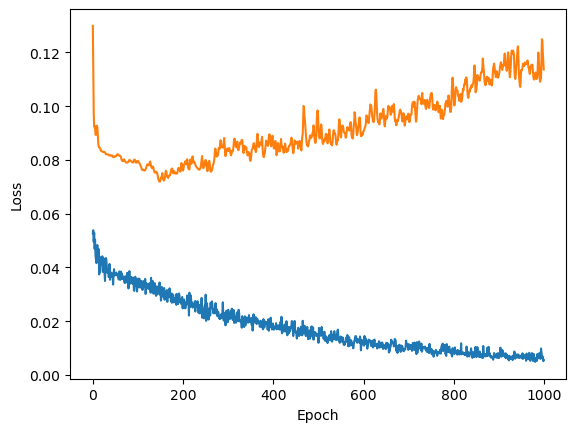

In [121]:
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

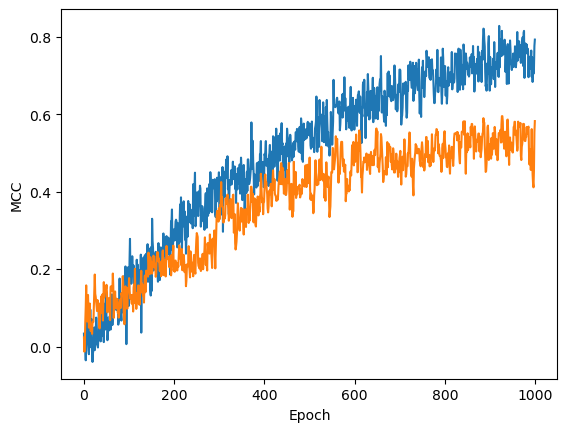

In [122]:
plt.plot(history.history["MatthewsCorrelationCoefficient"])
plt.plot(history.history["val_MatthewsCorrelationCoefficient"])
plt.xlabel("Epoch")
plt.ylabel("MCC")
plt.show()

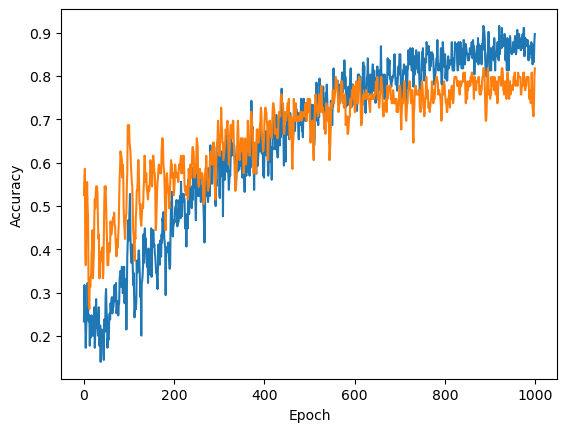

In [123]:
plt.plot(history.history["categorical_accuracy"])
plt.plot(history.history["val_categorical_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()
# dropout regularization

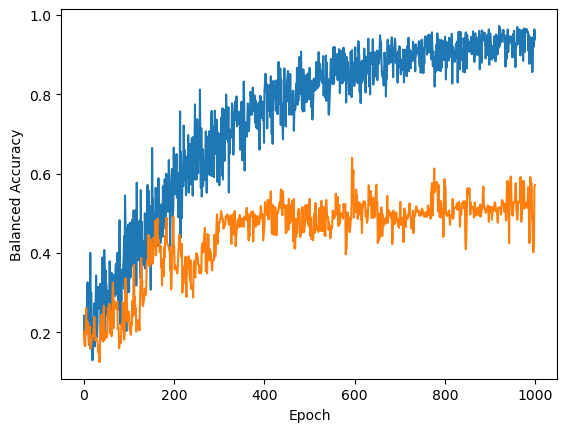

In [124]:
plt.plot(history.history["weighted_categorical_accuracy"])
plt.plot(history.history["val_weighted_categorical_accuracy"])
plt.xlabel("Epoch")
plt.ylabel("Balanced Accuracy")
plt.show()

Observe that the validation loss, after a first decreasing period, starts increasing again;
however the other metrics do not display this behaviour.
It is very likely that the model performs more and more badly on some examples,
which are classified wrongly with increasing certainty because of overfitting,
but it keeps improving on others, which switch predictions between classes.

### Evaluation

In [125]:
test_bools = records_df["patient"].isin(patients_test["patient"])
records_test = records_df[test_bools].copy()
records_test["ds_signals"] = records_test["signals"].apply(downsample)

In [126]:
y_pred_test = np.array([np.argmax(model(np.expand_dims(x, axis=0))) for x in records_test["ds_signals"]])

In [127]:
y_true_test = records_test["diagnosis"].apply(lambda x : train_generator_class.diagnosis2class[x]).values

In [128]:
balanced_accuracy_score(y_pred=y_pred_test, y_true=y_true_test)

0.2702362777171937

In [129]:
matthews_corrcoef(y_pred=y_pred_test, y_true=y_true_test)

0.2505122950904335

In [130]:
confusion_matrix(y_pred=y_pred_test, y_true=y_true_test)

array([[  2,   3,   1,   0,   1],
       [  2,   1,   0,   0,   3],
       [  1,   2,   0,   0,   3],
       [ 19,   1,   0,   1,  14],
       [ 14,   2,   1,   0, 114]])

In [131]:
metrics = {
    # "confusion_matrix": confusion_matrix,
    "accuracy": accuracy_score,
    "balanced_accuracy": balanced_accuracy_score,
    "matthews_corrcoef": matthews_corrcoef,
}

Bootstrap resampling to estimate the distribution of classification metrics for your model. It allows you to assess the robustness of your model's performance by considering different possible samples from your test dataset.

In [132]:
"""Estimate distribution of performance metrics for classification model."""
N_BOOTSTRAP = 100 # Number of bootstrap samples to generate (how many times the resampling process will be repeated)
rng = np.random.default_rng(42) # Initialize a random number generator
bootstrap_result = [] # Initialize an array to store the resampled statistics
patient_column_test = records_test["patient"]
test_patients = np.array(sorted(patient_column_test.unique()))
test_diagnosis = np.array([
    records_test["diagnosis"].iloc[np.argmax(patient_column_test == patient)]
    for patient in test_patients
])
for sample in tqdm(range(N_BOOTSTRAP)): # Perform bootstrap resampling ( In each iteration of the loop, a resampling process is performed.)
    y_true_patient = []
    y_pred_patient = []
    weight_patient = []
    for label in labels:
        label_test_patients = test_patients[test_diagnosis == label] # Identifies the test patients that belong to the current label.
        sampled_patients = rng.choice( # Randomly selects patients from the current label.
            a=label_test_patients,
            size=len(label_test_patients),
            replace=True,
        )
        for i, patient in enumerate(sampled_patients): # Iterates over the selected patients.
            y_true_patient.append(y_true_test[patient_column_test == patient]) # Stores the true labels of the selected patients.
            y_pred_patient.append(y_pred_test[patient_column_test == patient]) # Stores the predicted labels of the selected patients.
            weight_patient.append( # Assigns a weight to each patient based on the inverse of the number of patients in the same label group. This weight is used in metric calculations
                np.full_like(y_true_patient[-1], fill_value=1.0 / len(y_true_patient[-1]), dtype=float)
            )
    y_true_bootstrap = np.concatenate(y_true_patient) 
    y_pred_bootstrap = np.concatenate(y_pred_patient)
    weight_bootstrap = np.concatenate(weight_patient)
    for k, v in metrics.items(): # Calculates the metrics for the current bootstrap sample, with the weights assigned to each patient.
        bootstrap_result.append([
            sample,
            k,
            v(y_true=y_true_bootstrap, y_pred=y_pred_bootstrap, sample_weight=weight_bootstrap),
        ])
bootstrap_df = pd.DataFrame(bootstrap_result, columns=["sample", "metric", "value"])
bootstrap_df

  0%|          | 0/100 [00:00<?, ?it/s]

,sample,metric,value
0,0,accuracy,0.511847
1,0,balanced_accuracy,0.245489
2,0,matthews_corrcoef,0.152554
3,1,accuracy,0.578916
4,1,balanced_accuracy,0.336200
...,...,...,...
295,98,balanced_accuracy,0.188644
296,98,matthews_corrcoef,0.204397
297,99,accuracy,0.489157
298,99,balanced_accuracy,0.234400


In [133]:
px.box(bootstrap_df, x="metric", y="value")

Interpreting the box plots:

- The box plot provides a summary of the distribution of metric values, including the median, spread (IQR and whiskers), and potential outliers.
- The spread of values (e.g., the width of the box and length of the whiskers) indicates how consistent or variable the model's performance is across different samples.
- Outliers, if present, may suggest that the model performs exceptionally well or poorly in specific cases.

In general, you should focus on the median values as a central measure of performance and consider the spread to gauge the model's consistency. A narrow spread and fewer outliers suggest that the model is stable and provides consistent results. Conversely, a wide spread with many outliers may indicate variability in performance and the need for further investigation into model improvements or data quality.